In [ ]:
# %pip install statsmodels

## Time series are a series of data points indexed (or listed or graphed) in time order.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

import warnings
from itertools import product

import scipy.stats as scs
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.tsa.api as smt
from dateutil.relativedelta import relativedelta # working with dates with style
from scipy.optimize import minimize # for function minimization
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore") # `do not disturbe` mode

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


As an example, let’s look at real mobile game data. Specifically, we will look into ads watched per hour and in-game currency spend per day:

In [3]:
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

In [4]:
ads = pd.read_csv(DATA_PATH + "ads.csv", index_col=["Time"], parse_dates=["Time"])
currency = pd.read_csv(
    DATA_PATH + "currency.csv", index_col=["Time"], parse_dates=["Time"]
)
# index_col=["Time"] - use time col as index, so we can access rows like df.loc["2024-01-02"]
# parse_dates=["Time"] - tells pandas to convert the Time column from strings into datetime objects.

In [5]:
ads.head()

,Ads
Time,
2017-09-13 00:00:00,80115
2017-09-13 01:00:00,79885
2017-09-13 02:00:00,89325
2017-09-13 03:00:00,101930
2017-09-13 04:00:00,121630


In [6]:
currency.head()

,GEMS_GEMS_SPENT
Time,
2017-05-01,1199436
2017-05-02,1045515
2017-05-03,586111
2017-05-04,856601
2017-05-05,793775


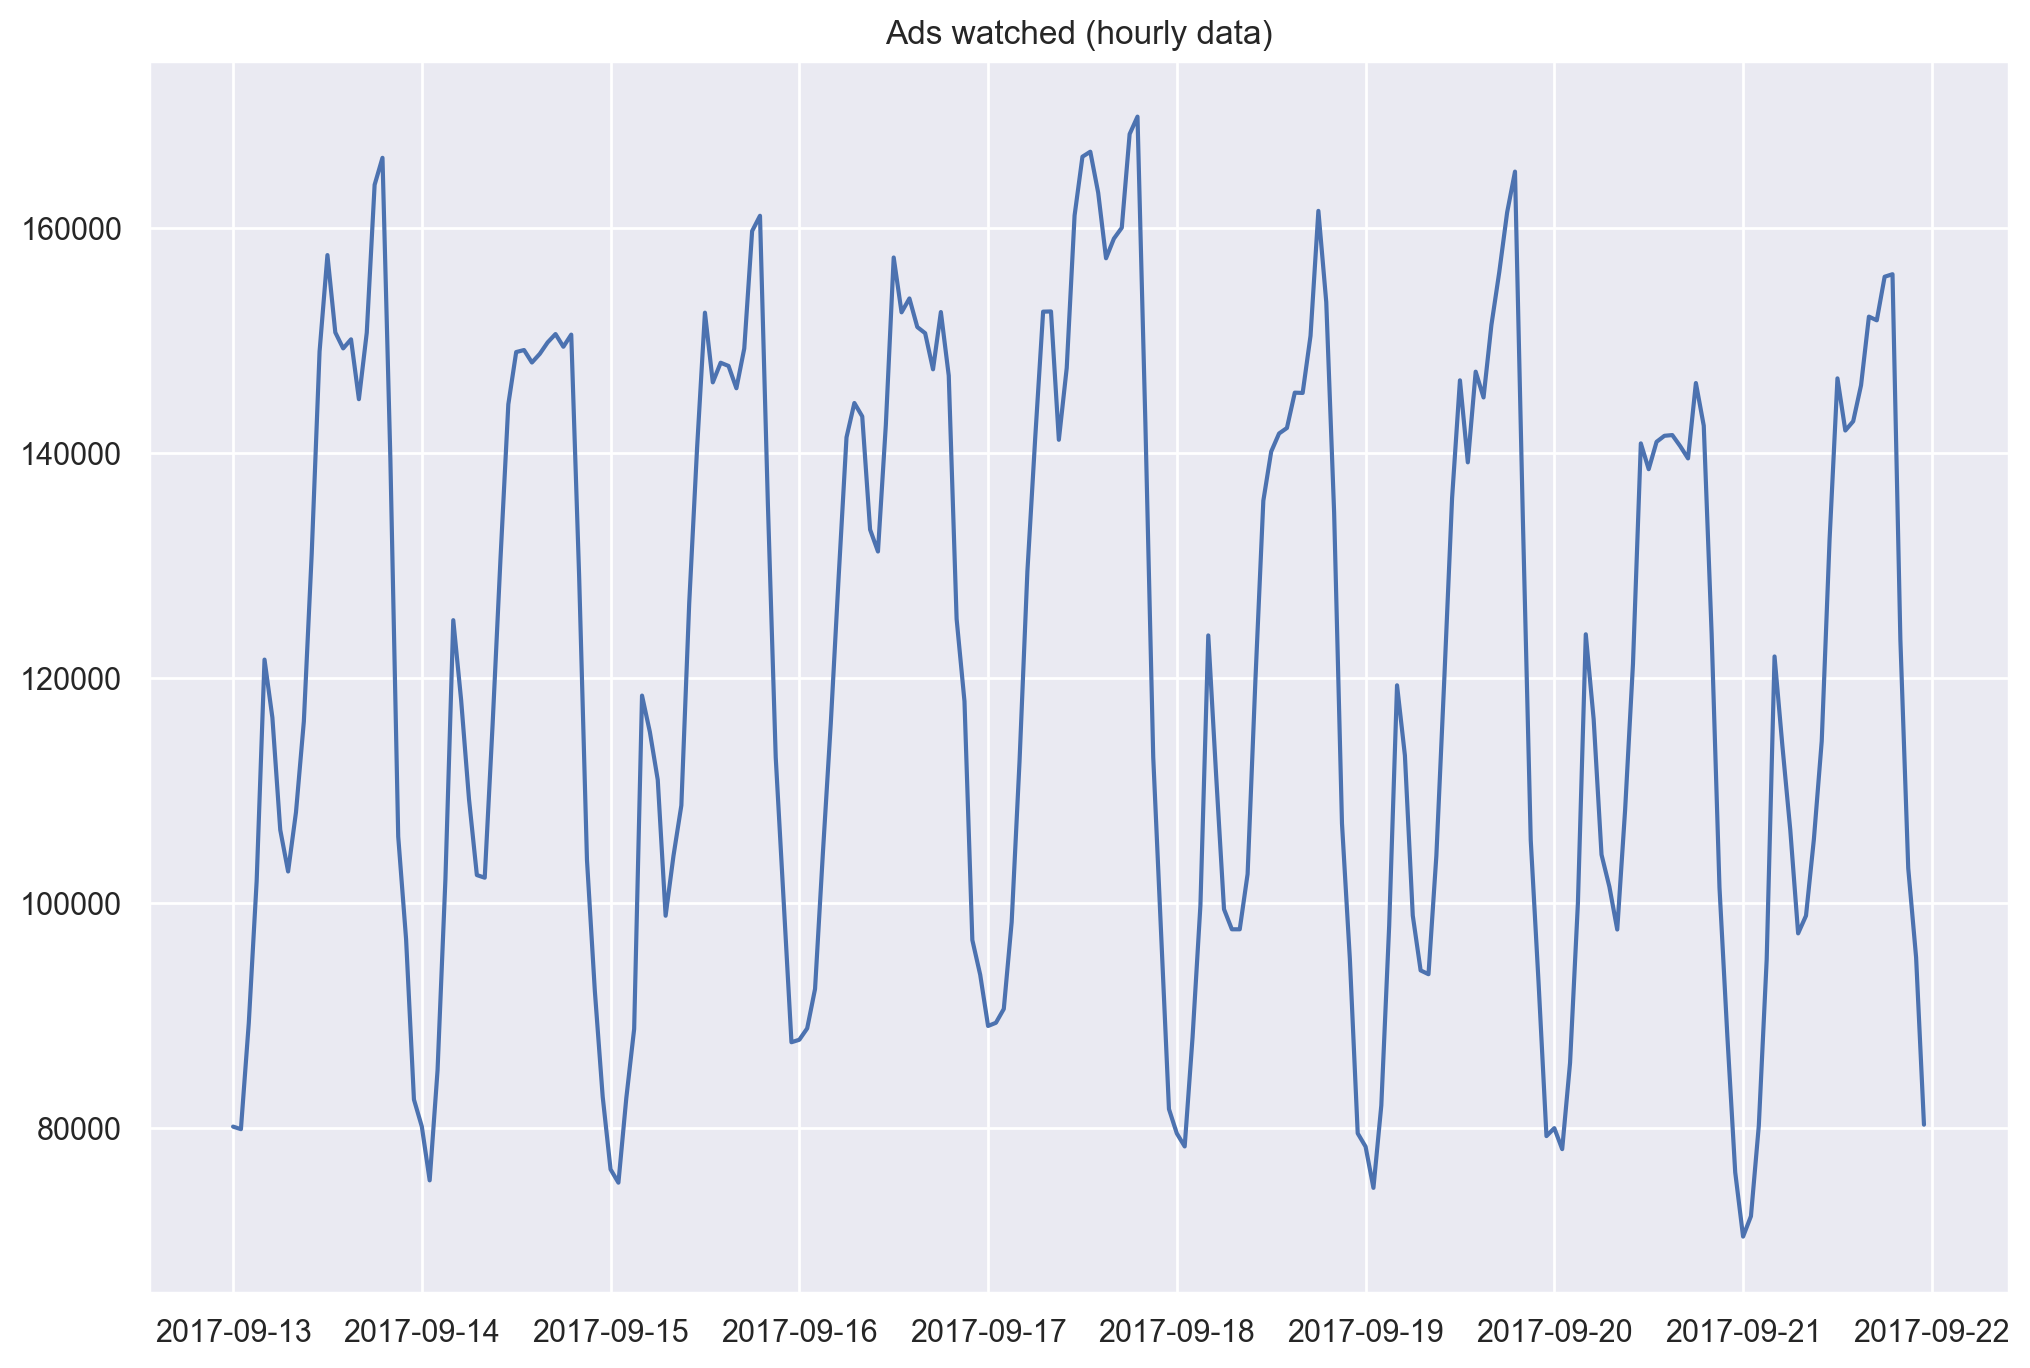

In [7]:
plt.figure(figsize=(12,8))
plt.plot(ads.Ads)
plt.title("Ads watched (hourly data)")
plt.grid(True)
plt.show()

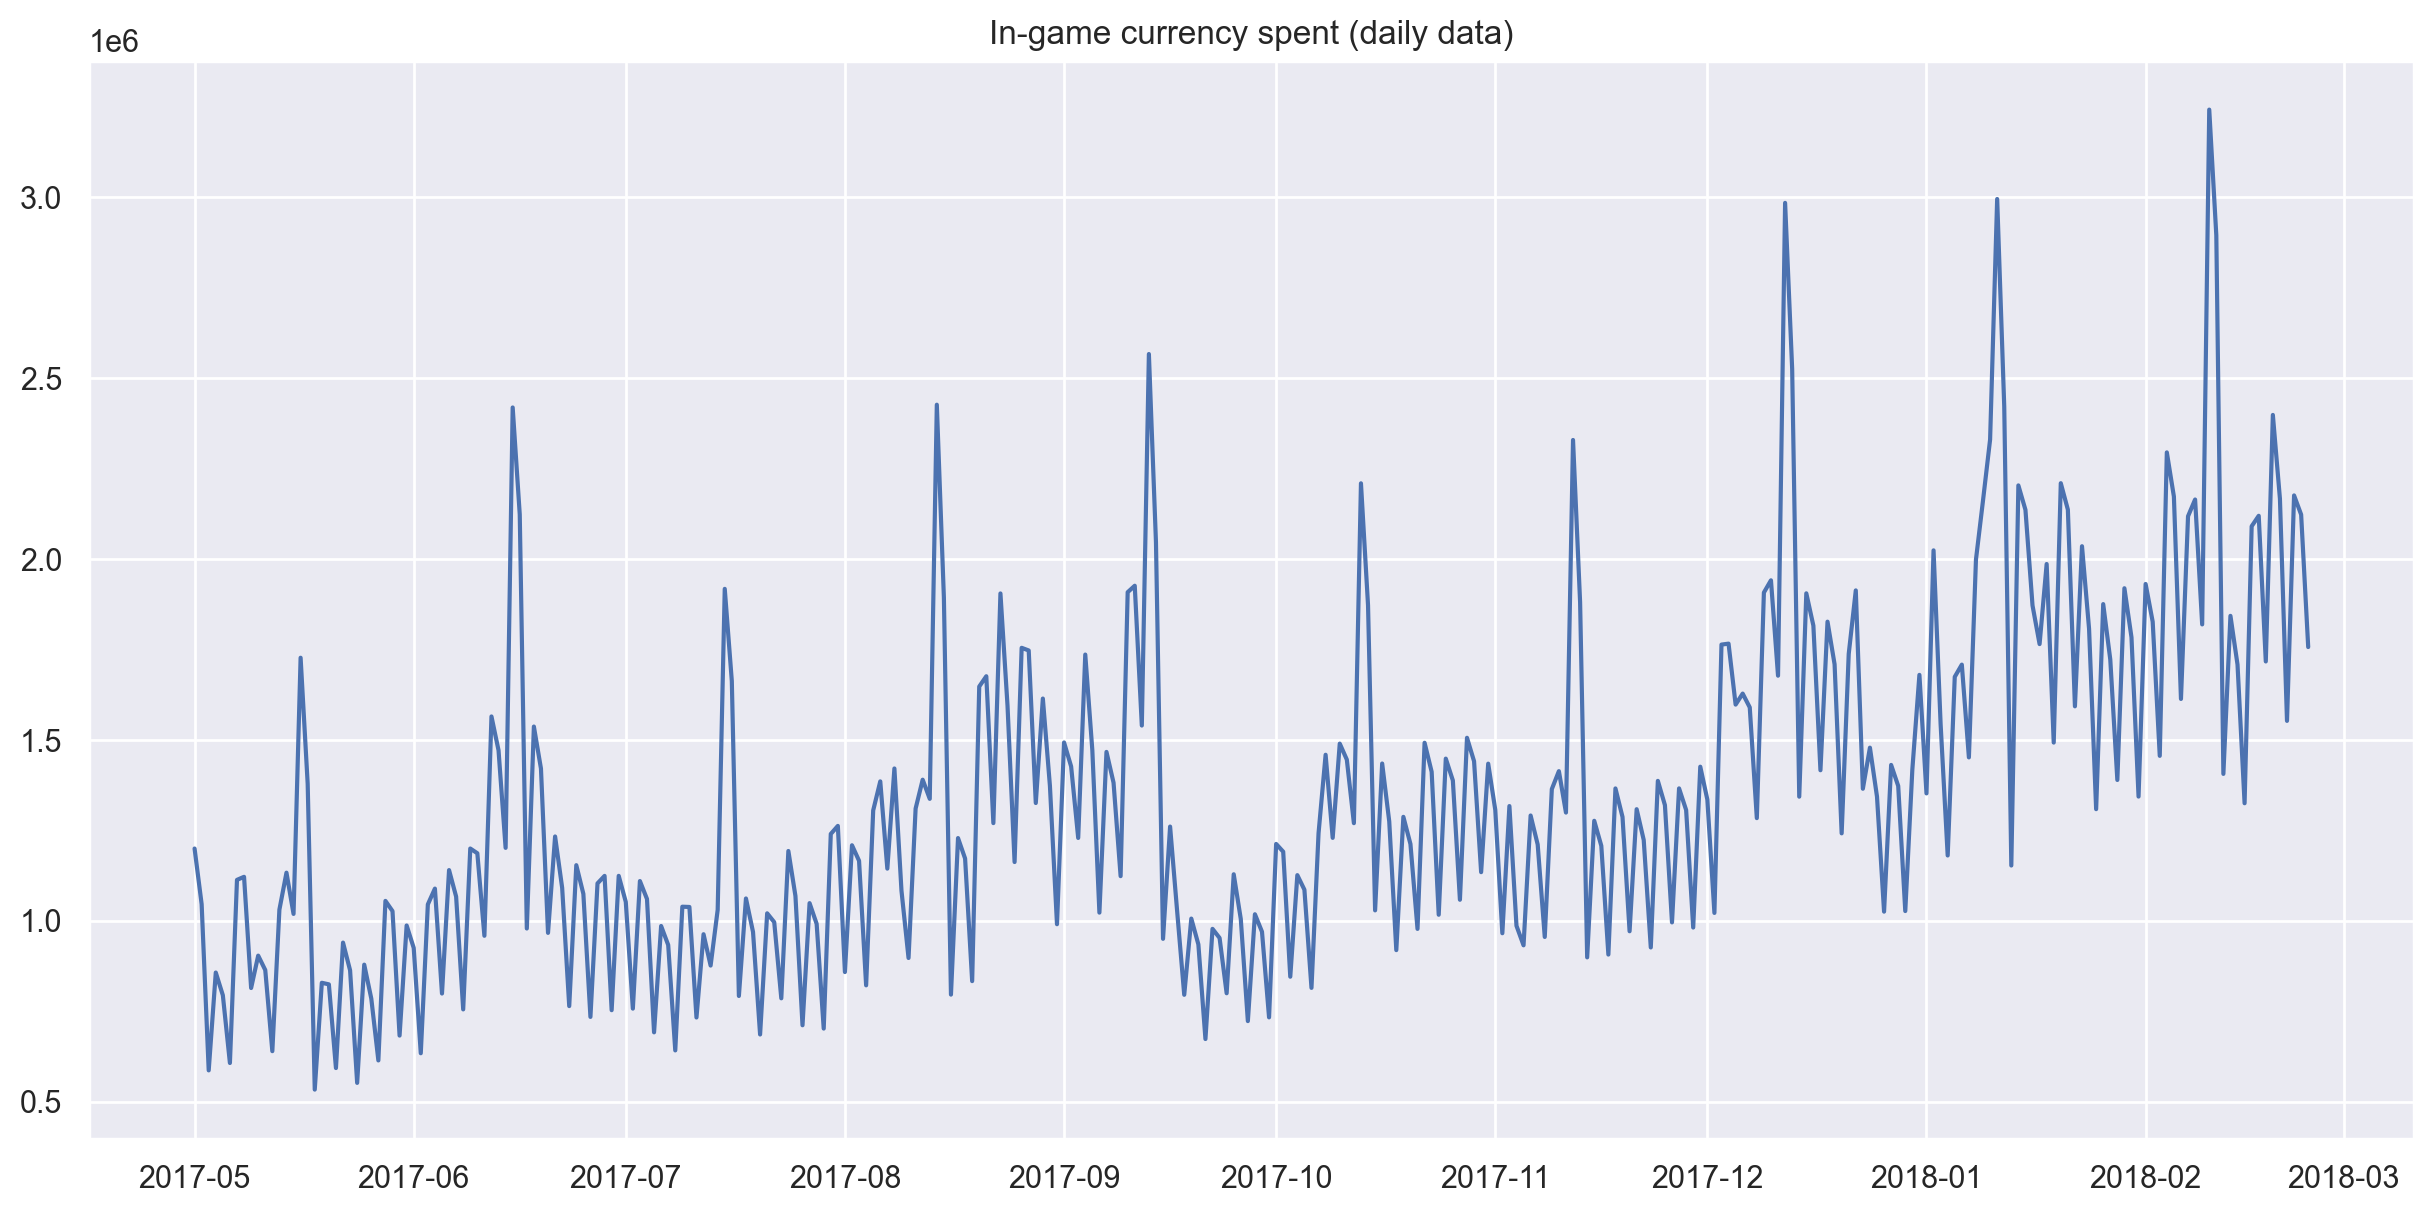

In [8]:
plt.figure(figsize=(15, 7))
plt.plot(currency.GEMS_GEMS_SPENT)
plt.title("In-game currency spent (daily data)")
plt.grid(True)
plt.show()

## Forecast quality metrics

In [9]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred) / y_true) * 100

In [10]:
# Importing everything

from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_squared_log_error, median_absolute_error,
                             r2_score)

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


Now that we know how to measure the quality of the forecasts, let’s see what metrics we can use and how to translate the results for the boss. After that, one small detail remains - building the model.

## Move, smoothe, evaluate

Let’s start with a naive hypothesis: “tomorrow will be the same as today”. However, instead of a model like $$ \hat{y}_{t} = y_{t-1} $$ (which is actually a great baseline for any time series prediction problems and sometimes is impossible to beat), we will assume that the future value of our variable depends on the average of its k previous values. Therefore, we will use the moving average.

In [11]:
import numpy as np
a = [1,2,3,4,5,6,7,8]
a[-5:]
# np.average(a[-8])

[4, 5, 6, 7, 8]

In [12]:
addds = ads.rolling(window=4).mean()
addds

,Ads
Time,
2017-09-13 00:00:00,NaN
2017-09-13 01:00:00,NaN
2017-09-13 02:00:00,NaN
2017-09-13 03:00:00,87813.75
2017-09-13 04:00:00,98192.50
...,...
2017-09-21 19:00:00,153866.25
2017-09-21 20:00:00,146685.00
2017-09-21 21:00:00,134507.50


In [13]:
def moving_average(series, n):
    # calculate the average of the last n observations
    return np.average(series[-n:])

moving_average(ads, 24)  # prediction for the last observed day (past 24 hours)

np.float64(116805.0)

Unfortunately, we cannot make predictions far in the future - in order to get the value for the next step, we need the previous values to be actually observed. But moving average has another use case - smoothing the original time series to identify trends. Pandas has an implementation available with DataFrame.rolling(window).mean(). The wider the window, the smoother the trend. In the case of very noisy data, which is often encountered in finance, this procedure can help detect common patterns.

## code explanation

# 1. What is the function doing?

Imagine you have daily temperatures:

| Day | Temperature |
| --- | ----------: |
| 1   |          20 |
| 2   |          21 |
| 3   |          19 |
| 4   |          22 |
| 5   |          23 |
| 6   |          25 |
| 7   |          24 |

If we use a **3-day moving average**, each point becomes the average of the previous 3 days.

For Day 3:

$$
(20+21+19)/3 = 20
$$

For Day 4:

$$
(21+19+22)/3 = 20.67
$$

and so on.

This smooths out noisy fluctuations.

This line computes it:

```python
rolling_mean = series.rolling(window=window).mean()
```

---

# 2. Plotting the moving average

```python
plt.plot(rolling_mean, "g", label="Rolling mean trend")
```

This draws the moving average as a green line.

Suppose the original data looks like:

```
Actual:
20 22 18 24 21 25 23
```

Moving average:

```
20 21 21 23 23
```

The green line is smoother than the original data.

---

# 3. What does `plot_intervals` do?

This is the interesting part.

Instead of only drawing the moving average, it draws a **band around it**.

Imagine the moving average is

```
50
52
51
53
54
```

The real data will almost never be exactly equal to these numbers.

It might be

```
49
53
50
55
52
```

The code asks:

> "How far away are the real values from the moving average, on average?"

---

## Step A: Compute MAE

```python
mae = mean_absolute_error(series[window:], rolling_mean[window:])
```

MAE = Mean Absolute Error.

Suppose

| Actual | Moving Avg | Difference |
| -----: | ---------: | ---------: |
|     49 |         50 |          1 |
|     53 |         52 |          1 |
|     50 |         51 |          1 |
|     55 |         53 |          2 |
|     52 |         54 |          2 |

Absolute differences:

```
1
1
1
2
2
```

Average:

$$
(1+1+1+2+2)/5 = 1.4
$$

So

```python
mae = 1.4
```

This means:

> On average, the actual data is 1.4 units away from the moving average.

---

## Step B: Compute deviation

```python
deviation = np.std(series[window:] - rolling_mean[window:])
```

This calculates the **standard deviation of the errors**.

Suppose the errors are

```
-1
+1
0
+2
-2
```

Standard deviation measures how spread out these errors are.

Small deviation:

```
-1
0
1
```

Large deviation:

```
-10
5
20
-15
```

So deviation measures how "noisy" the data is.

---

## Step C: Build upper and lower bounds

```python
lower_bond = rolling_mean - (mae + scale * deviation)
upper_bond = rolling_mean + (mae + scale * deviation)
```

Suppose

```
rolling_mean = 100
```

MAE = 3

Deviation = 4

Scale = 1.96

Then

```
margin = 3 + 1.96 × 4
       = 10.84
```

So

```
Upper = 110.84

Lower = 89.16
```

Instead of saying

> expected value = 100

we now say

> expected value is probably between **89.16 and 110.84**.

Graphically:

```
Upper --------------------------
               |
Moving Avg ---------------------
               |
Lower --------------------------
```

The code plots these:

```python
plt.plot(upper_bond, "r--")
plt.plot(lower_bond, "r--")
```

So you'll see two red dashed lines surrounding the green moving average.

---

# Why multiply by 1.96?

```python
scale = 1.96
```

1.96 comes from statistics.

For data that is roughly normally distributed, about **95%** of observations lie within ±1.96 standard deviations of the mean.

So this creates an approximate **95% confidence band** around the moving average. It's not a rigorous confidence interval for forecasting, but it's a practical threshold for spotting unusual values.

---

# 4. What does `plot_anomalies` do?

This is where the intervals become useful.

The idea is simple:

> If a value is outside the upper or lower bound, it's unusual.

---

Suppose the moving average is

```
100
100
100
100
100
```

Bounds are

```
Upper =110

Lower =90
```

Actual values:

```
99
103
97
125
101
```

The value

```
125
```

is above 110.

So it is marked as an anomaly.

Similarly,

```
85
```

would be below 90.

---

The code:

```python
anomalies = pd.DataFrame(index=series.index, columns=series.columns)
```

creates an empty dataframe.

Initially:

| Value |
| ----- |
| NaN   |
| NaN   |
| NaN   |
| NaN   |

---

Then

```python
anomalies[series < lower_bond] = series[series < lower_bond]
```

If a value is below the lower bound:

```
Actual = 85

Lower = 90
```

Since

```
85 < 90
```

store it.

Now:

| Value |
| ----- |
| NaN   |
| 85    |
| NaN   |
| NaN   |

---

Similarly,

```python
anomalies[series > upper_bond] = series[series > upper_bond]
```

Suppose

```
Actual = 125

Upper =110
```

Then

```
125 >110
```

Store it.

Final dataframe:

| Value |
| ----- |
| NaN   |
| 85    |
| NaN   |
| 125   |

---

Finally,

```python
plt.plot(anomalies, "ro", markersize=10)
```

plots only those points.

`"ro"` means:

* `r` = red
* `o` = circle marker

So anomalies appear as large red dots on the graph.

---

# Complete picture

Suppose your graph looks like this:

```
Actual values

125 •                    <-- anomaly

110 -------------------- Upper bound

100 ==================== Moving average

90  -------------------- Lower bound

85 •                     <-- anomaly
```

Everything between the dashed lines is considered "normal."

Anything outside gets highlighted.

---

# Summary of the logic

```
                Original Data
                     │
                     ▼
        Compute Moving Average
                     │
                     ▼
      Measure typical prediction error
      (MAE + standard deviation)
                     │
                     ▼
 Create upper and lower bounds around
      the moving average
                     │
                     ▼
     Is actual value outside bounds?
            /               \
         Yes                 No
         │                   │
         ▼                   ▼
 Plot red anomaly        Consider normal
```

So in simple terms:

* **`rolling_mean`** gives the smoothed trend.
* **`plot_intervals=True`** draws a "normal range" (red dashed lines) around that trend based on historical error and variability.
* **`plot_anomalies=True`** checks every data point; if it falls outside that normal range, it is marked with a **red circle** as a potential anomaly.


In [14]:
def plotMovingAverage(series, window, plot_intervals=False, scale=1.96, plot_anomalies=False):
    """
        series - dataframe with timeseries
        window - rolling window size
        plot_intervals - show confidence intervals
        plot_anomalies - show anomalies

    """
    rolling_mean = series.rolling(window=window).mean()

    plt.figure(figsize=(15, 5))
    plt.title("Moving average\n window size = {}".format(window))
    plt.plot(rolling_mean, "g", label="Rolling mean trend")

    # plot confidence intervals for smoothed values
    if plot_intervals:
        mae = mean_absolute_error(series[window:], rolling_mean[window:])
        deviation = np.std(series[window:] - rolling_mean[window:])
        lower_bond = rolling_mean - (mae + scale * deviation)
        upper_bond = rolling_mean + (mae + scale * deviation)
        plt.plot(upper_bond, "r--", label="Upper Bond / Lower Bond")
        plt.plot(lower_bond, "r--")

        # Having the intervals, find abnormal values
        if plot_anomalies:
            anomalies = pd.DataFrame(index=series.index, columns=series.columns)
            anomalies[series < lower_bond] = series[series < lower_bond]
            anomalies[series > upper_bond] = series[series > upper_bond]
            plt.plot(anomalies, "ro", markersize=10)

    plt.plot(series[window:], label="Actual values")
    plt.legend(loc="upper left")
    plt.grid(True)

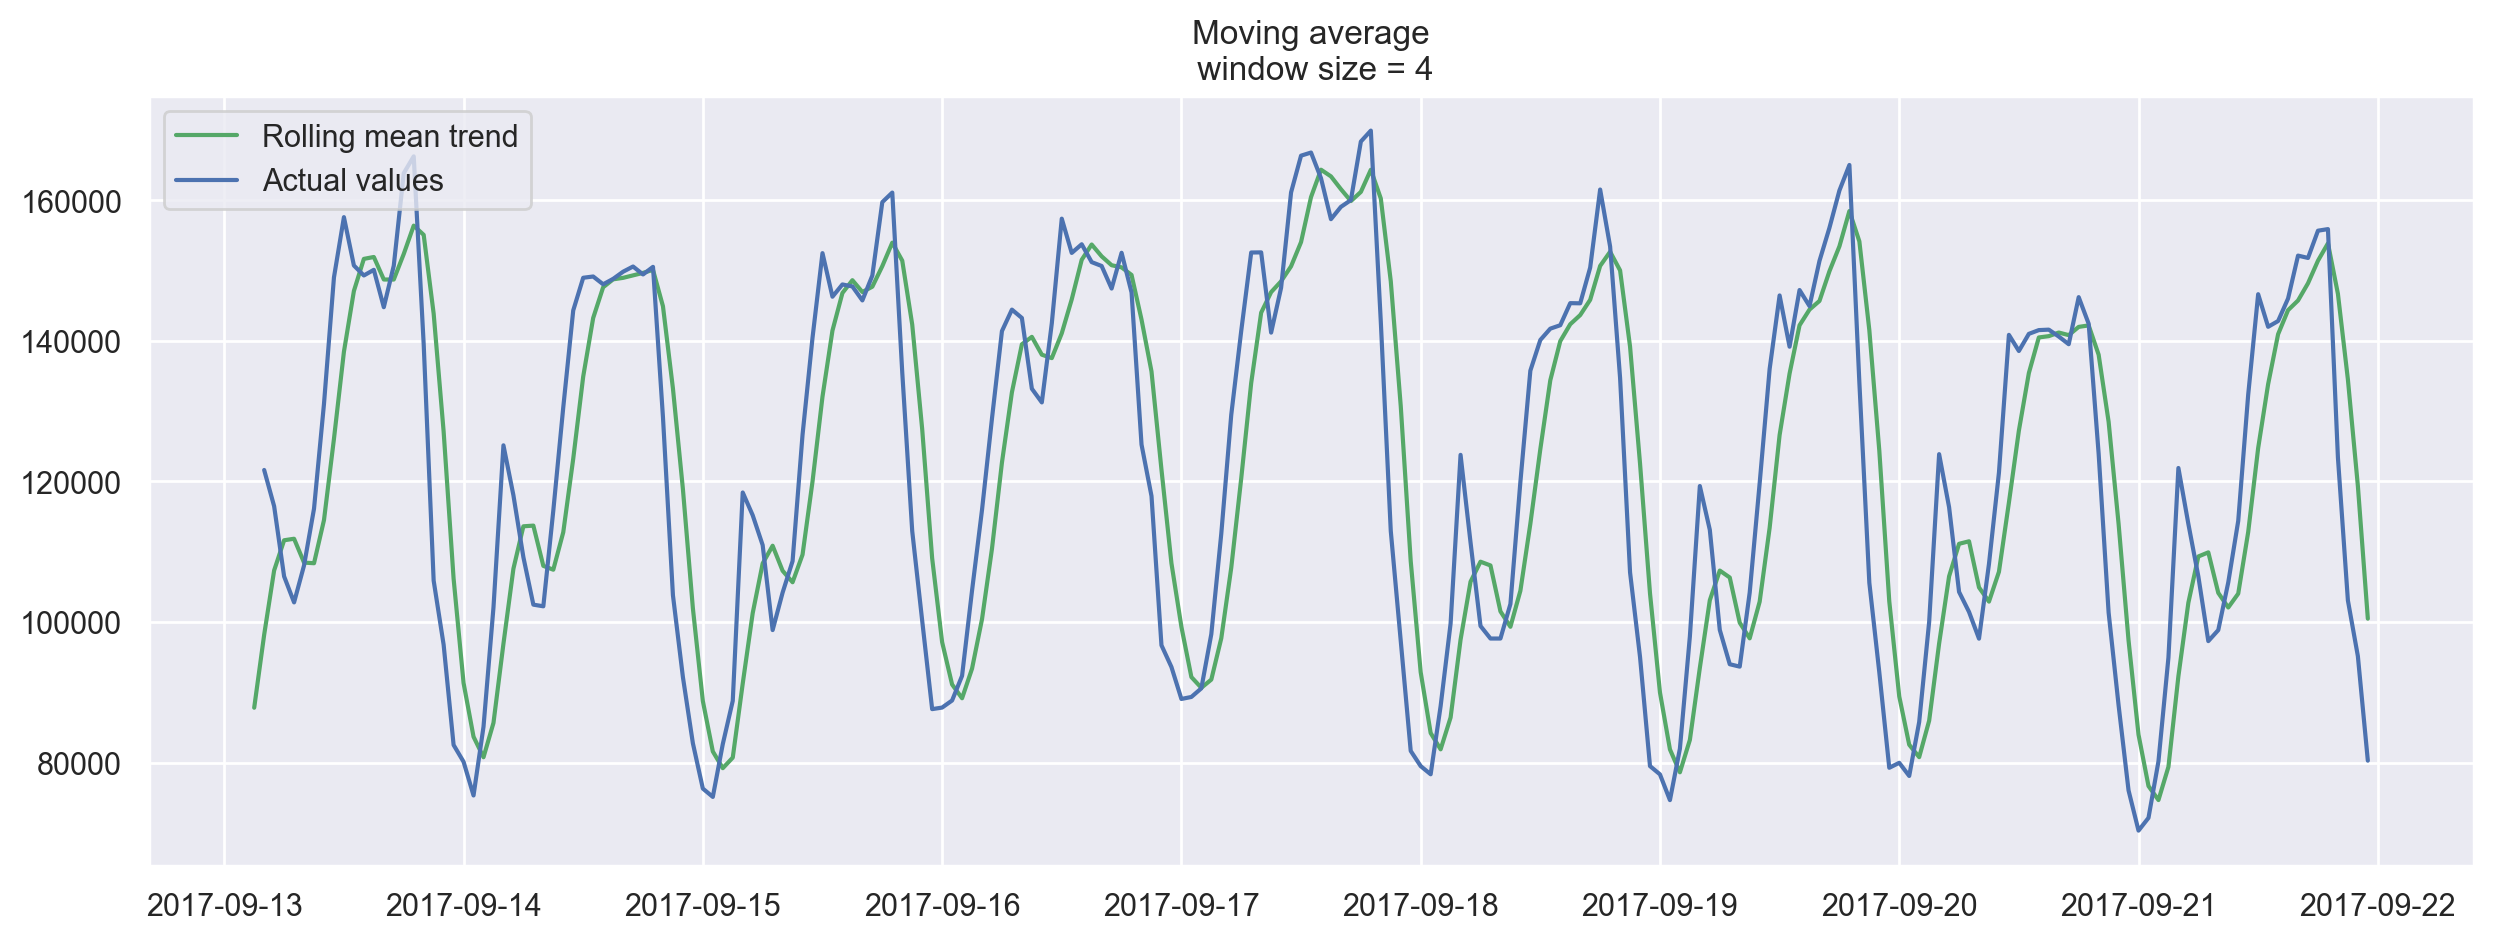

In [15]:
plotMovingAverage(ads, 4)

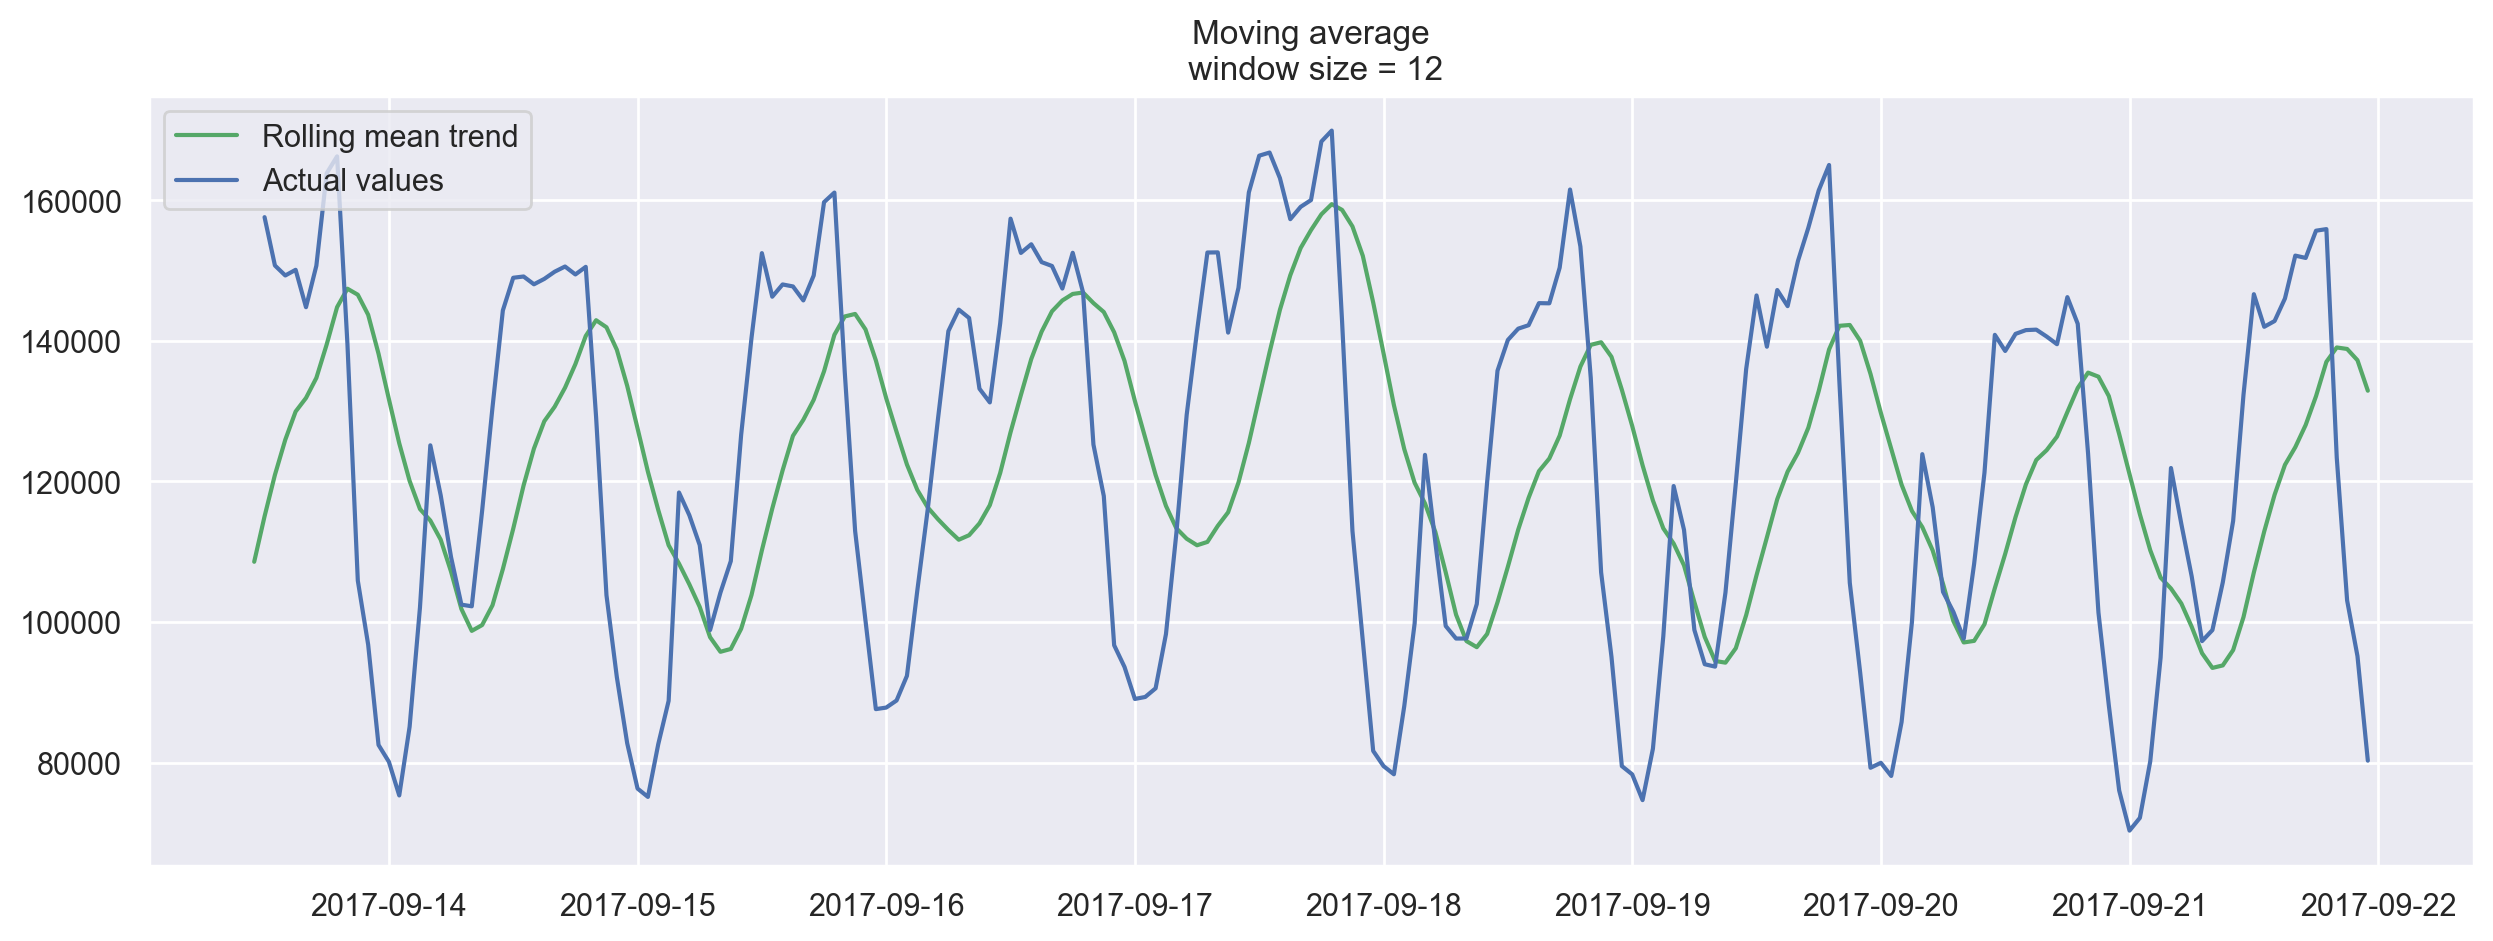

In [16]:
plotMovingAverage(ads, 12)

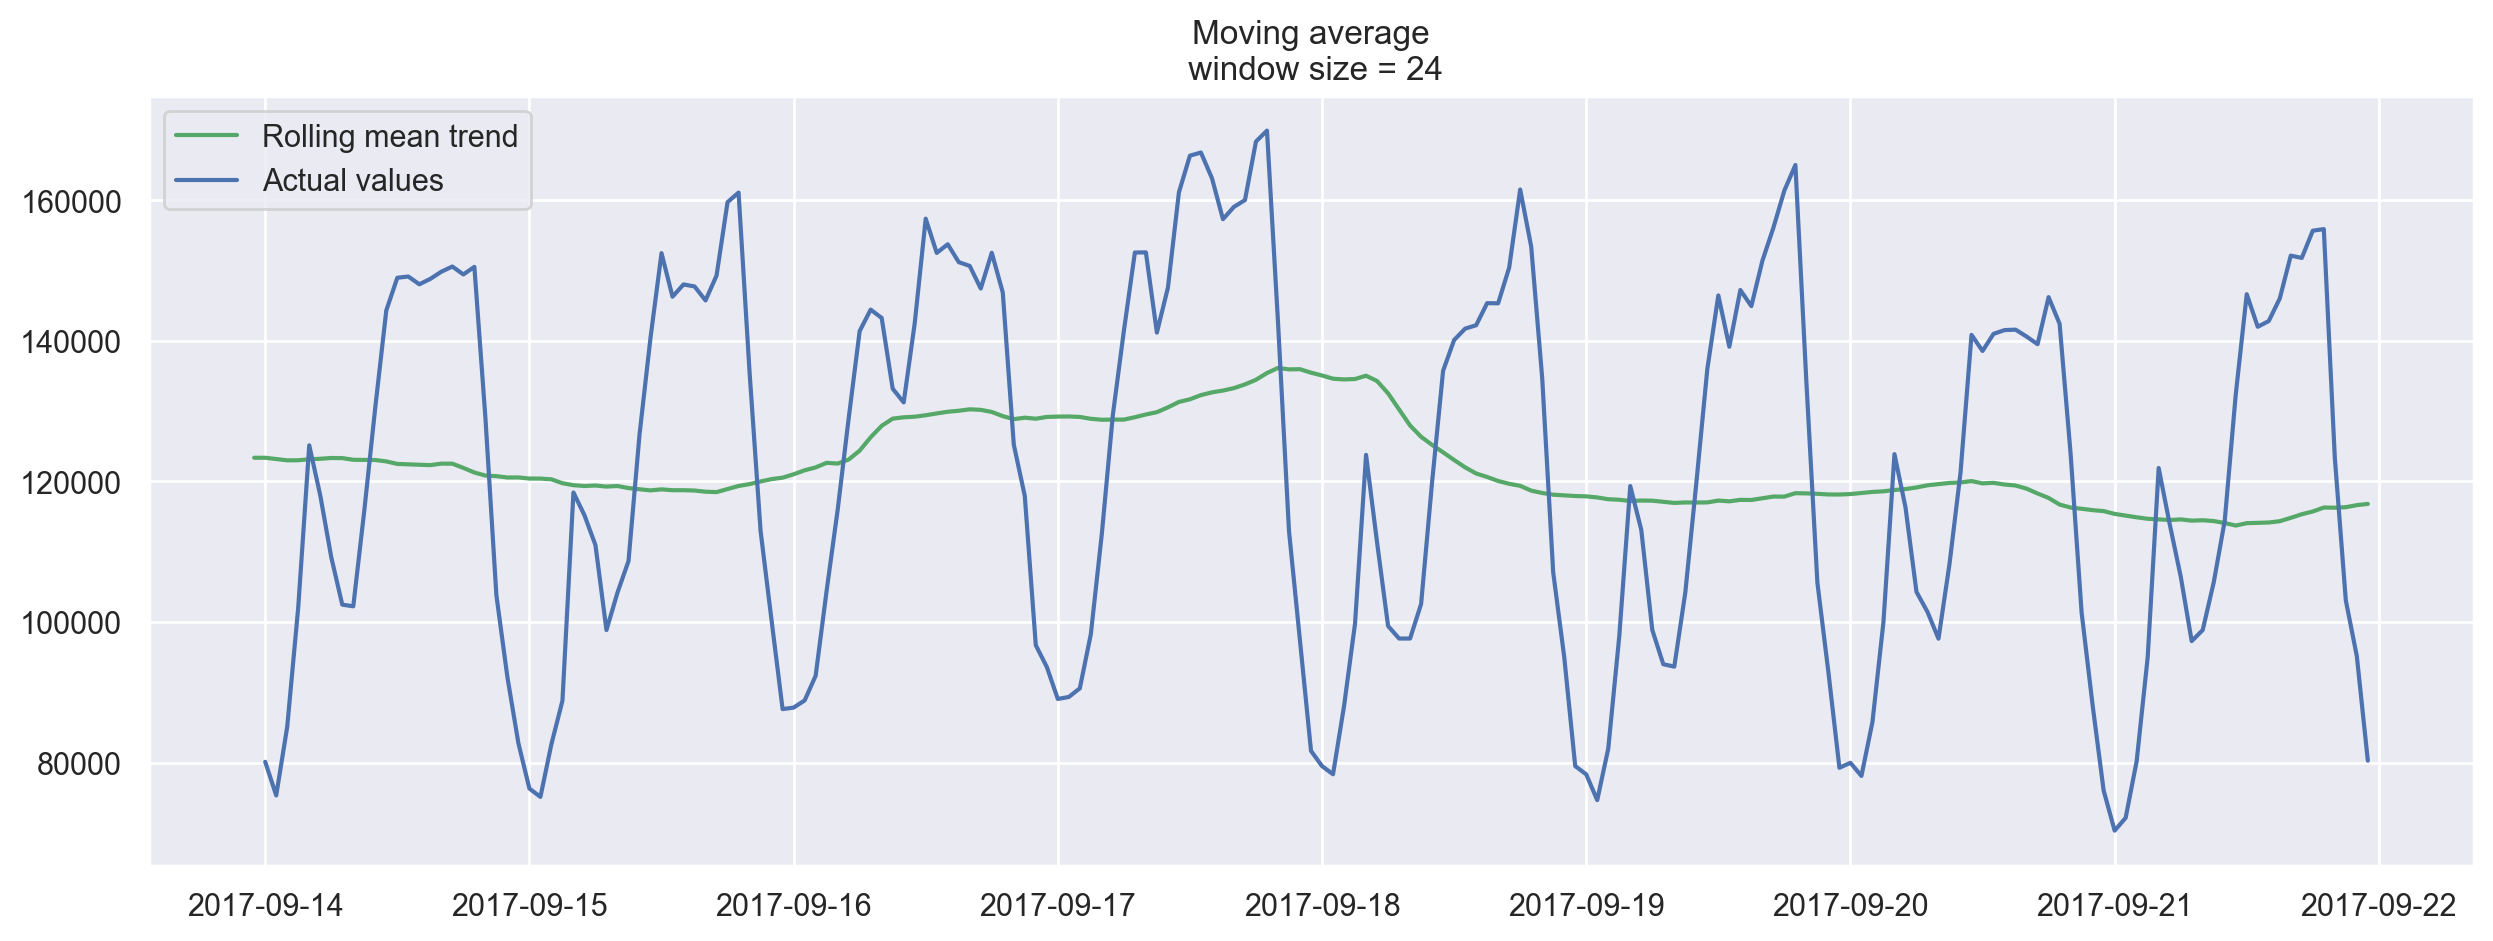

In [17]:
plotMovingAverage(ads, 24)

When we applied daily smoothing on hourly data, we could clearly see the dynamics of ads watched. During the weekends, the values are higher (more time to play on the weekends) while fewer ads are watched on weekdays.

We can also plot confidence intervals for our smoothed values.

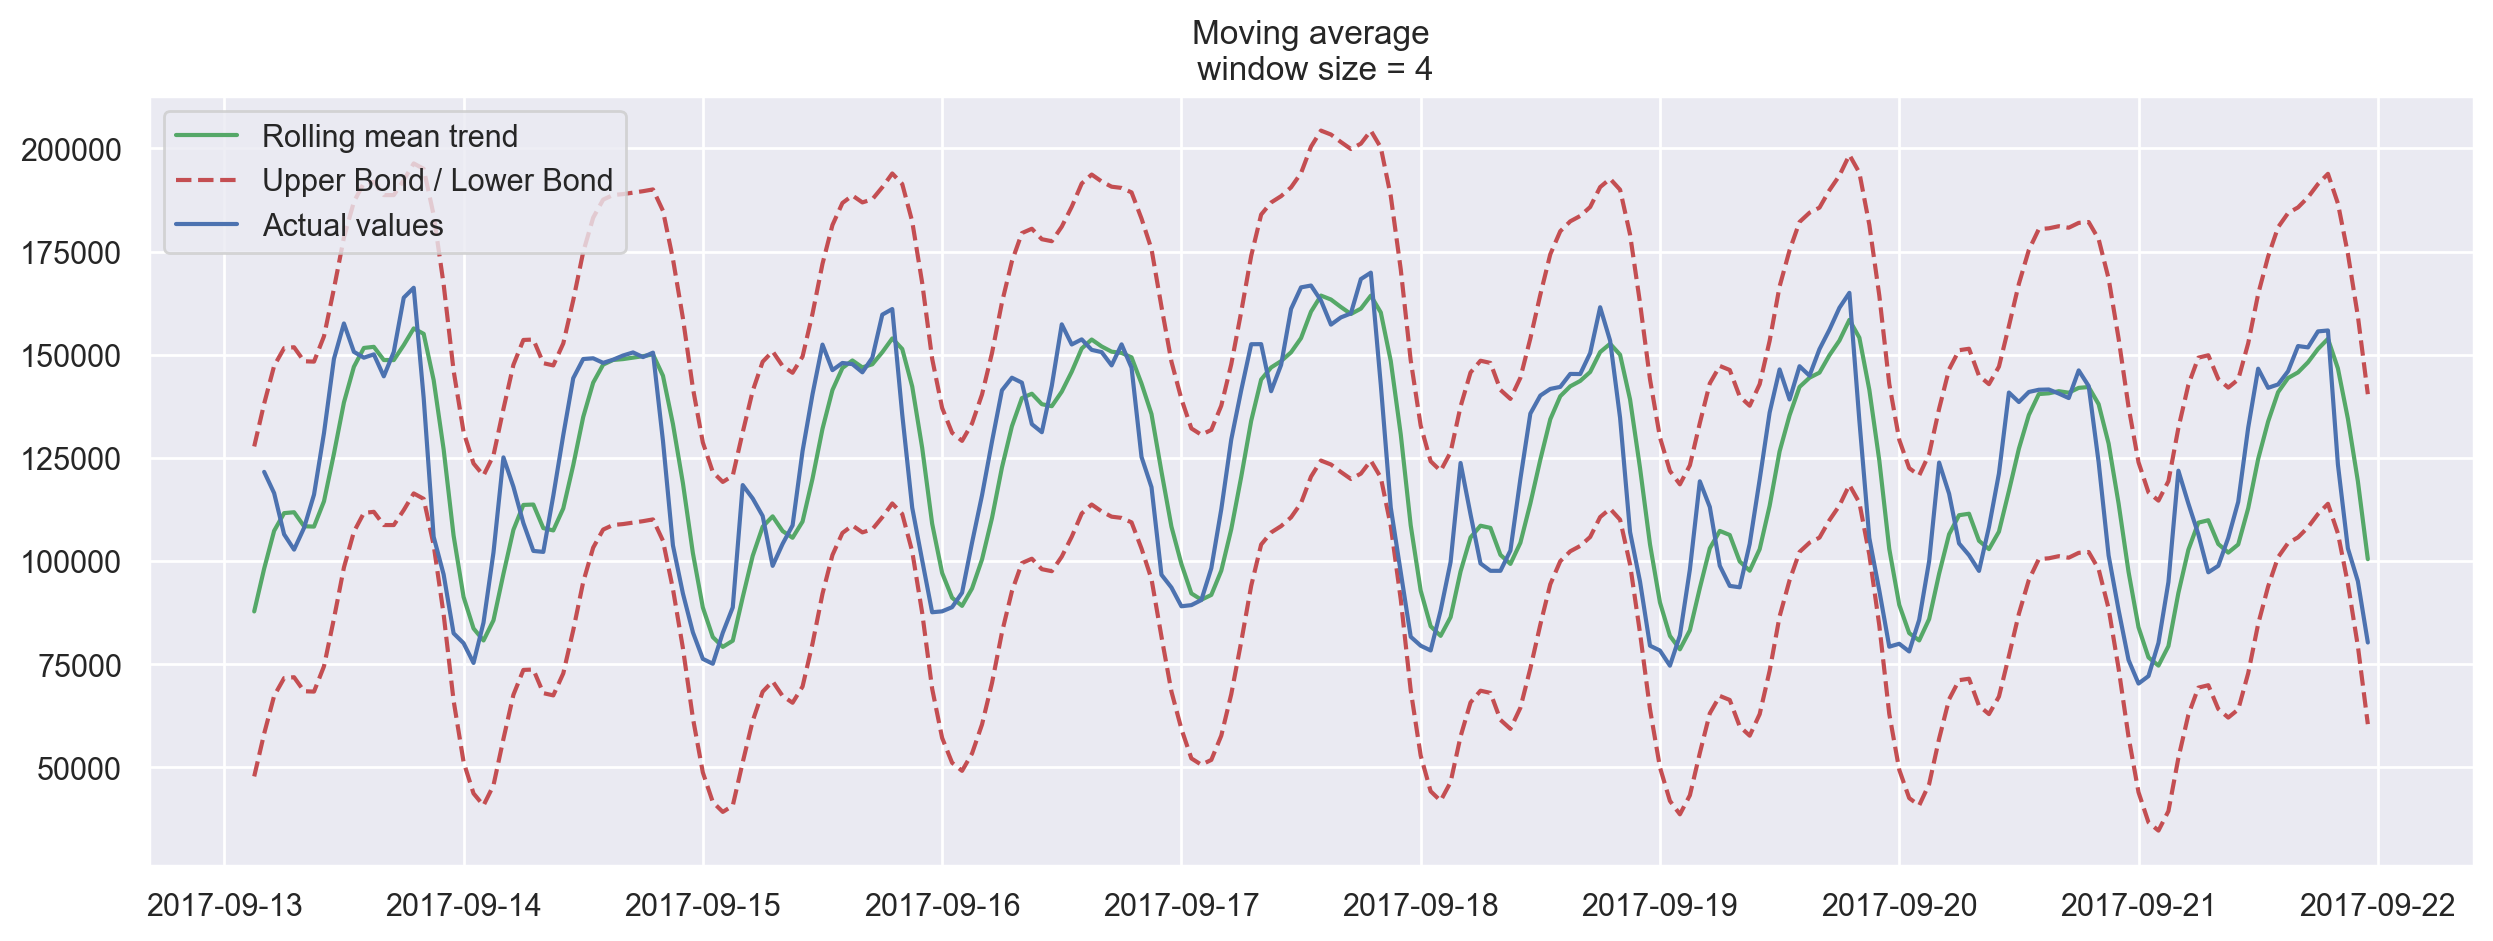

In [18]:
plotMovingAverage(ads, 4, plot_intervals=True)

Now, let’s create a simple anomaly detection system with the help of moving average. Unfortunately, in this particular dataset, everything is more or less normal, so we will intentionally make one of the values abnormal in our dataframe ads_anomaly.

In [19]:
ads_anomaly = ads.copy()
ads_anomaly.iloc[-20] = ads_anomaly.iloc[-20] * 0.2  # say we have 80% drop of ads

Let’s see if this simple method can catch the anomaly.

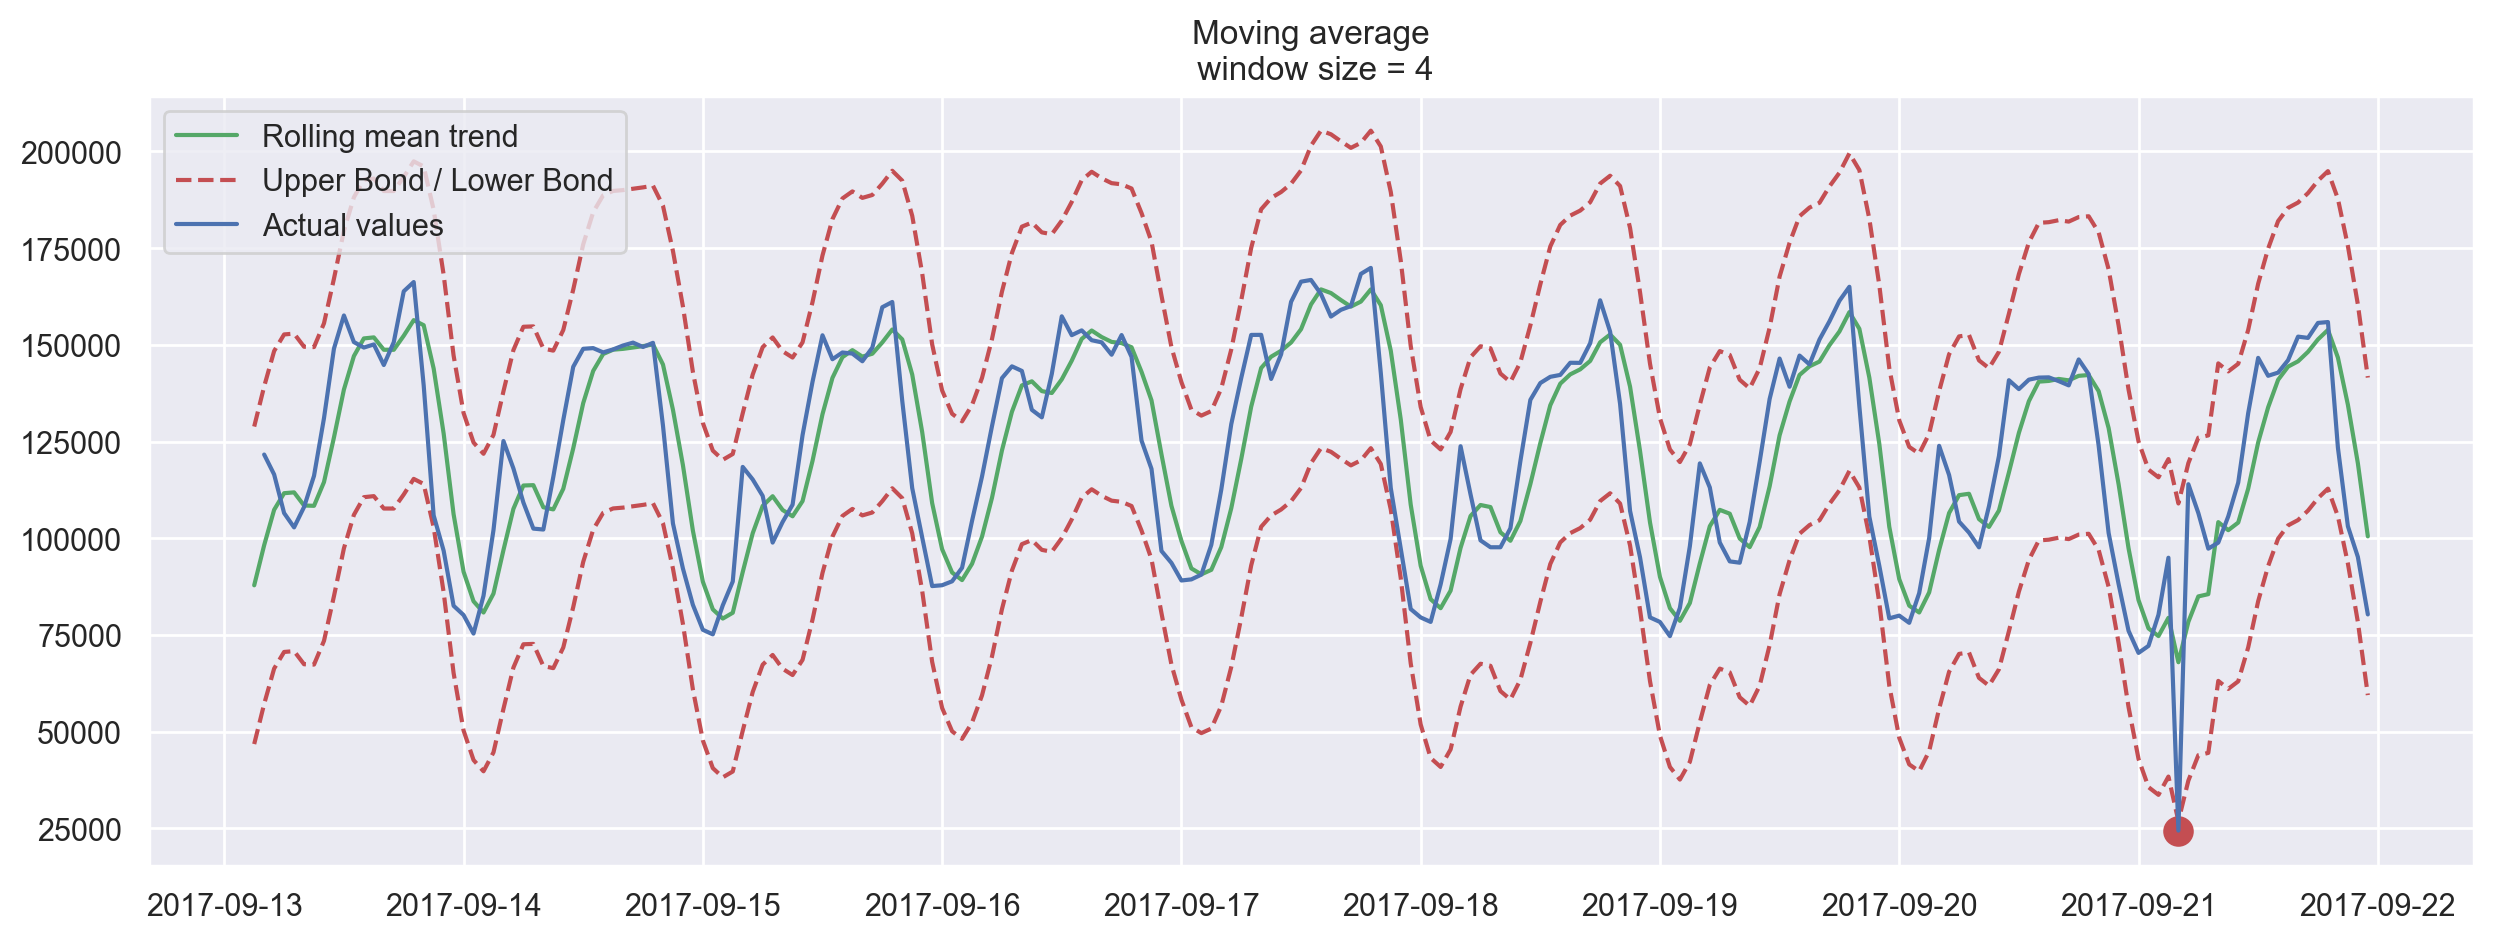

In [20]:
plotMovingAverage(ads_anomaly, 4, plot_intervals=True, plot_anomalies=True)

what about the second series

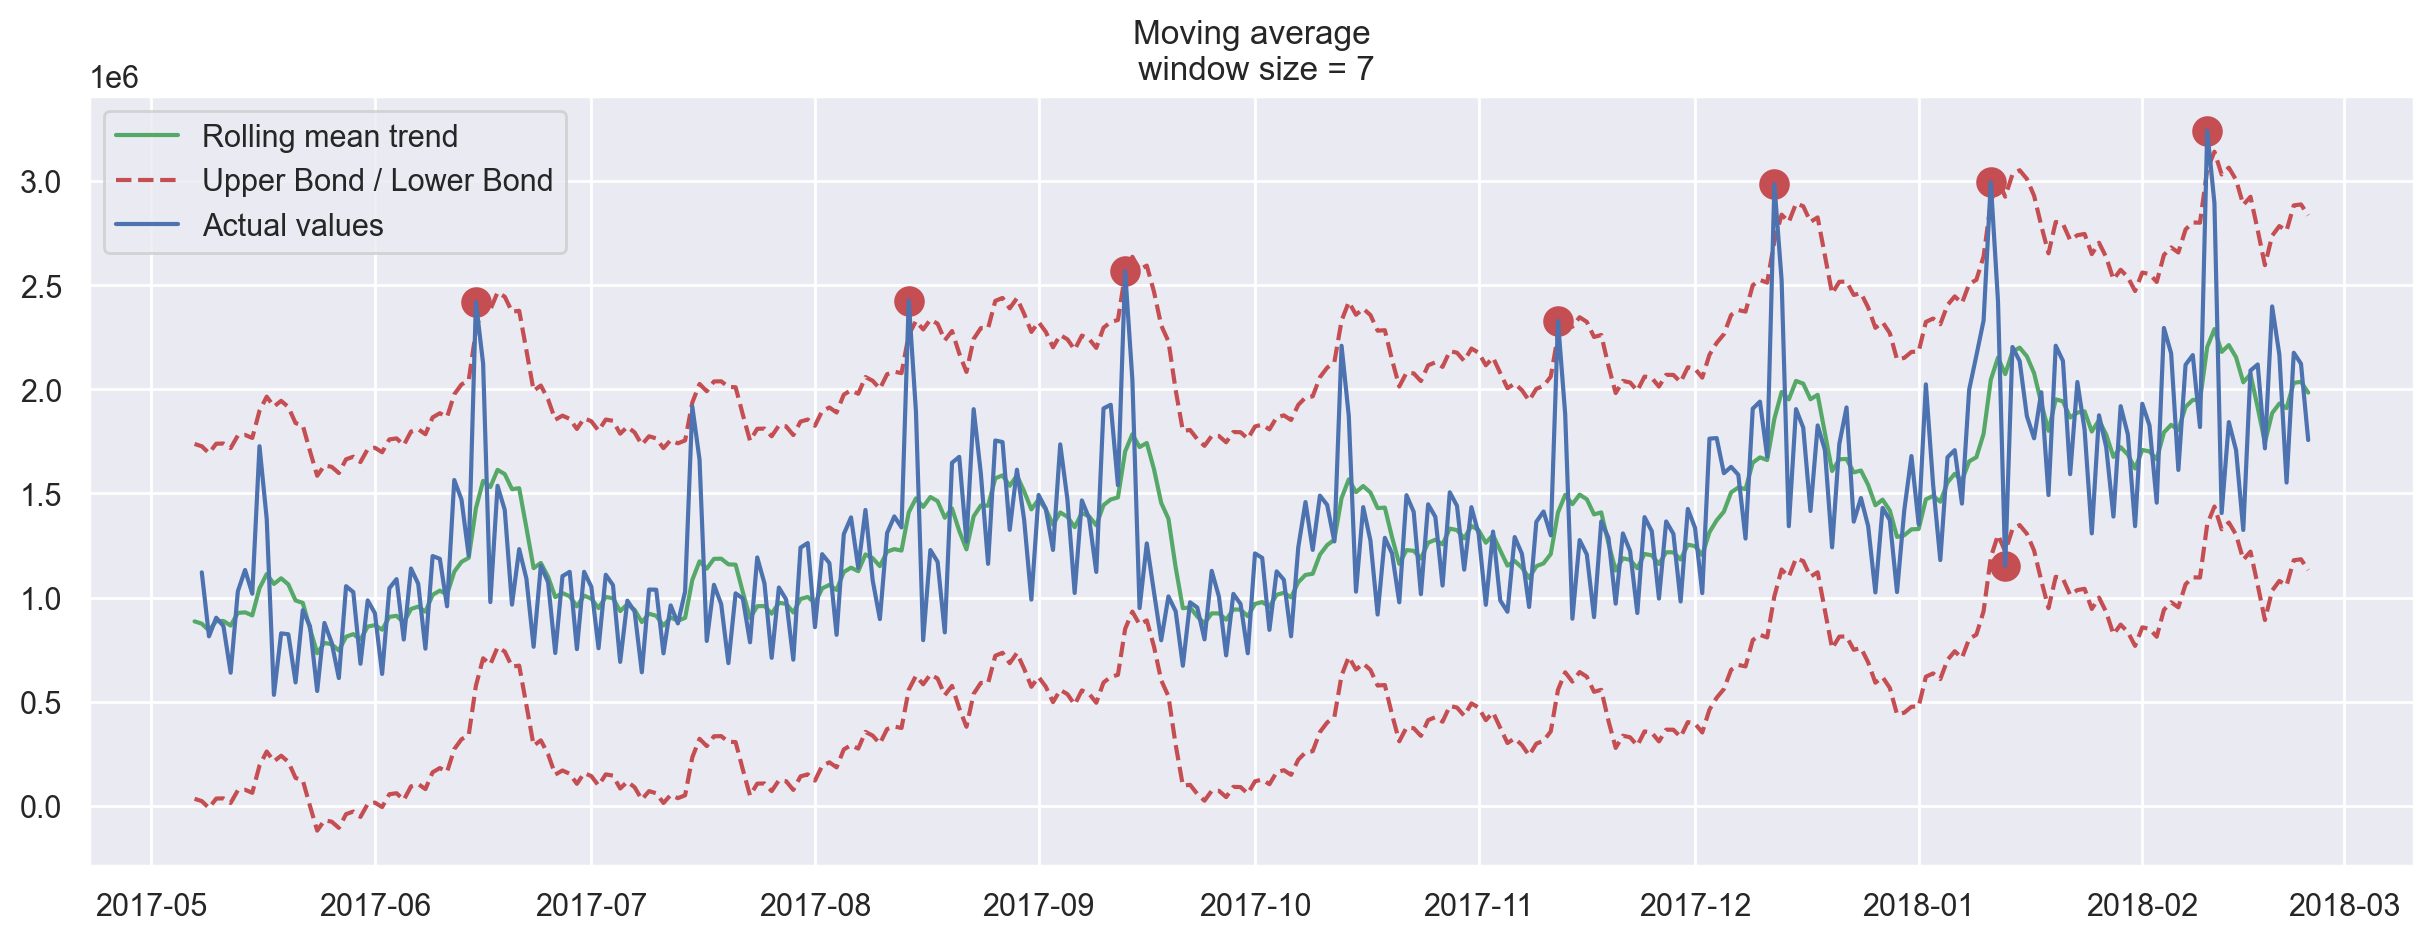

In [21]:
plotMovingAverage(
    currency, 7, plot_intervals=True, plot_anomalies=True
)  # weekly smoothing

Here, we can see the downside of our simple approach – it did not capture the monthly seasonality in our data and marked almost all 30-day peaks as anomalies. If you want to avoid false positives, it is best to consider more complex models.

### means

This is actually one of the **big limitations of using a simple moving average for anomaly detection**. Let's break down exactly what the author means.

---

## First, look at your graph

You have:

* **Blue line** → actual currency values
* **Green line** → 7-day moving average
* **Red dashed lines** → expected normal range (upper/lower bounds)
* **Red circles** → detected anomalies

Notice something interesting:

Almost every month there's a **very large spike**.

For example:

```
June      ↑
July      ↑
August    ↑
September ↑
October   ↑
November  ↑
December  ↑
January   ↑
```

The algorithm marks nearly every one of these spikes as an anomaly.

---

## But are they really anomalies?

Probably **not**.

Suppose this is the sales of a company.

```
Day 1-29 : around 100
Day 30   : 250
```

Every month:

```
Month 1
100 101 98 ... 250

Month 2
102 97 100 ... 245

Month 3
99 101 103 ... 255
```

The company always has a huge sale at the end of the month.

Those spikes are **expected**.

They happen every month.

They're part of the data's behavior.

So they are **seasonality**, not anomalies.

---

## What is seasonality?

Seasonality means a pattern repeats at regular intervals.

Examples:

### Example 1: Ice cream sales

```
Winter : 50
Summer : 300
Winter : 60
Summer : 320
```

Every summer sales increase.

Those increases are expected.

---

### Example 2: Electricity usage

```
Morning : high
Afternoon : medium
Night : low

Morning : high
Afternoon : medium
Night : low
```

Daily pattern repeats.

---

### Example 3: Salary deposits

Suppose everyone's salary is deposited on the last day of the month.

```
28th : $2,000
29th : $2,100
30th : $8,000
```

Every month:

```
...
30th : huge spike
```

That's not unusual.

---

## Why does the moving average fail?

You used

```python
window = 7
```

A 7-day moving average only "looks back" one week.

It has **no idea** that something special happens every 30 days.

It thinks:

> "Whoa! Yesterday was around 1 million.
>
> Today it's 3 million.
>
> That's way outside my normal range."

So it says:

**Anomaly!**

---

Imagine this:

```
Previous week

100
102
99
101
100
98
101
```

Moving average:

```
100
```

Then suddenly

```
250
```

The algorithm compares

```
Expected = 100

Actual = 250
```

Difference = 150

Huge!

So it marks it red.

But if this happens every month...

```
Month 1 : 250
Month 2 : 248
Month 3 : 252
Month 4 : 249
```

then it isn't abnormal at all.

The algorithm simply doesn't know that.

---

## What the author means

When they write:

> "it did not capture the monthly seasonality"

they mean:

The model only understands **short-term changes** (7 days).

It doesn't understand the repeating monthly pattern.

---

When they say

> "marked almost all 30-day peaks as anomalies"

they mean:

Every monthly spike is outside the confidence interval.

So the algorithm thinks

```
Spike → anomaly
Spike → anomaly
Spike → anomaly
Spike → anomaly
```

even though they're completely normal.

---

## What would a better model do?

A better model first learns:

```
Every 30 days...

↑

there is usually a spike.
```

Then when another spike comes:

```
Expected = spike

Actual = spike

Not anomaly.
```

Only if something unusual happens...

```
Expected = 2.5 million

Actual = 5 million
```

would it say

```
Anomaly!
```

---

## Visual comparison

### What the moving average thinks

```
100
100
100
100
250  <-- WOW!! anomaly!!
100
100
```

---

### Reality

```
100
100
100
100
250  <-- happens every month
100
100
```

So the spike is normal.

---

## What are these "more complex models"?

Models that explicitly account for **trend + seasonality** before looking for anomalies. Some common examples are:

| Model                                           | What it learns                                                                                            |
| ----------------------------------------------- | --------------------------------------------------------------------------------------------------------- |
| **Holt-Winters (Triple Exponential Smoothing)** | Trend + repeating seasonality (weekly, monthly, yearly).                                                  |
| **SARIMA (Seasonal ARIMA)**                     | Forecasts time series while modeling seasonal patterns (e.g., every 30 days).                             |
| **Prophet** (by Meta)                           | Automatically models trend, multiple seasonalities, and holidays.                                         |
| **STL Decomposition**                           | Separates a series into **Trend + Seasonality + Residual**. Anomalies are then detected in the residuals. |

For your graph, a seasonal model would learn:

```
Normal behavior:

Week 1  → around 1.0M
Week 2  → around 1.2M
Week 3  → around 1.1M
End of month → around 3.0M
```

So a spike to **3.0M** at the end of each month would be considered **expected**, while an unexpected spike to **5.0M** (or a missing spike when one is expected) would be flagged as an anomaly. This greatly reduces the false positives you see with the simple 7-day moving average approach.


Weighted average is a simple modification to the moving average. The weights sum up to 1 with larger weights assigned to more recent observations.

In [22]:
def weighted_average(series, weights):
    """
        Calculate weighted average on the series.
        Assuming weights are sorted in descending order
        (larger weights are assigned to more recent observations).
    """
    result = 0
    for n in range(len(weights)):
        result += series.iloc[-n - 1] * weights[n]

    return float(result)

In [23]:
weighted_average(ads, [0.6, 0.3, 0.1])

87025.5

In [24]:
# just checking
0.6 * ads.iloc[-1] + 0.3 * ads.iloc[-2] + 0.1 * ads.iloc[-3]

Ads    87025.5
dtype: float64

## Exponential smoothing

Now, let’s see what happens if, instead of weighting the last k values of the time series, we start weighting all available observations while exponentially decreasing the weights as we move further back in time. There exists a formula for exponential smoothing that will help us with this

In [25]:
def exponential_smoothing(series, alpha):
    """
        series - dataset with timestamps
        alpha - float [0.0, 1.0], smoothing parameter
    """
    result = [series[0]]
    for n in range(1, len(series)):
        result.append(alpha * series[n] + (1 - alpha) * result[n - 1])

    return result 

In [29]:
def plotExponentialSmoothing(series, alphas):
    """
        Plots exponential smoothing with different alphas

        series - dataset with timestamps
        alphas - list of floats, smoothing parameters

    """

    with plt.style.context("bmh"):
        plt.figure(figsize=(15, 7))
        for alpha in alphas:
            plt.plot(
                exponential_smoothing(series, alpha), label="Alpha {}".format(alpha)
            )
        plt.plot(series.values, "c", label="Actual")
        plt.legend(loc="best")
        plt.axis("tight")
        plt.title("Exponential Smoothing")
        plt.grid(True)

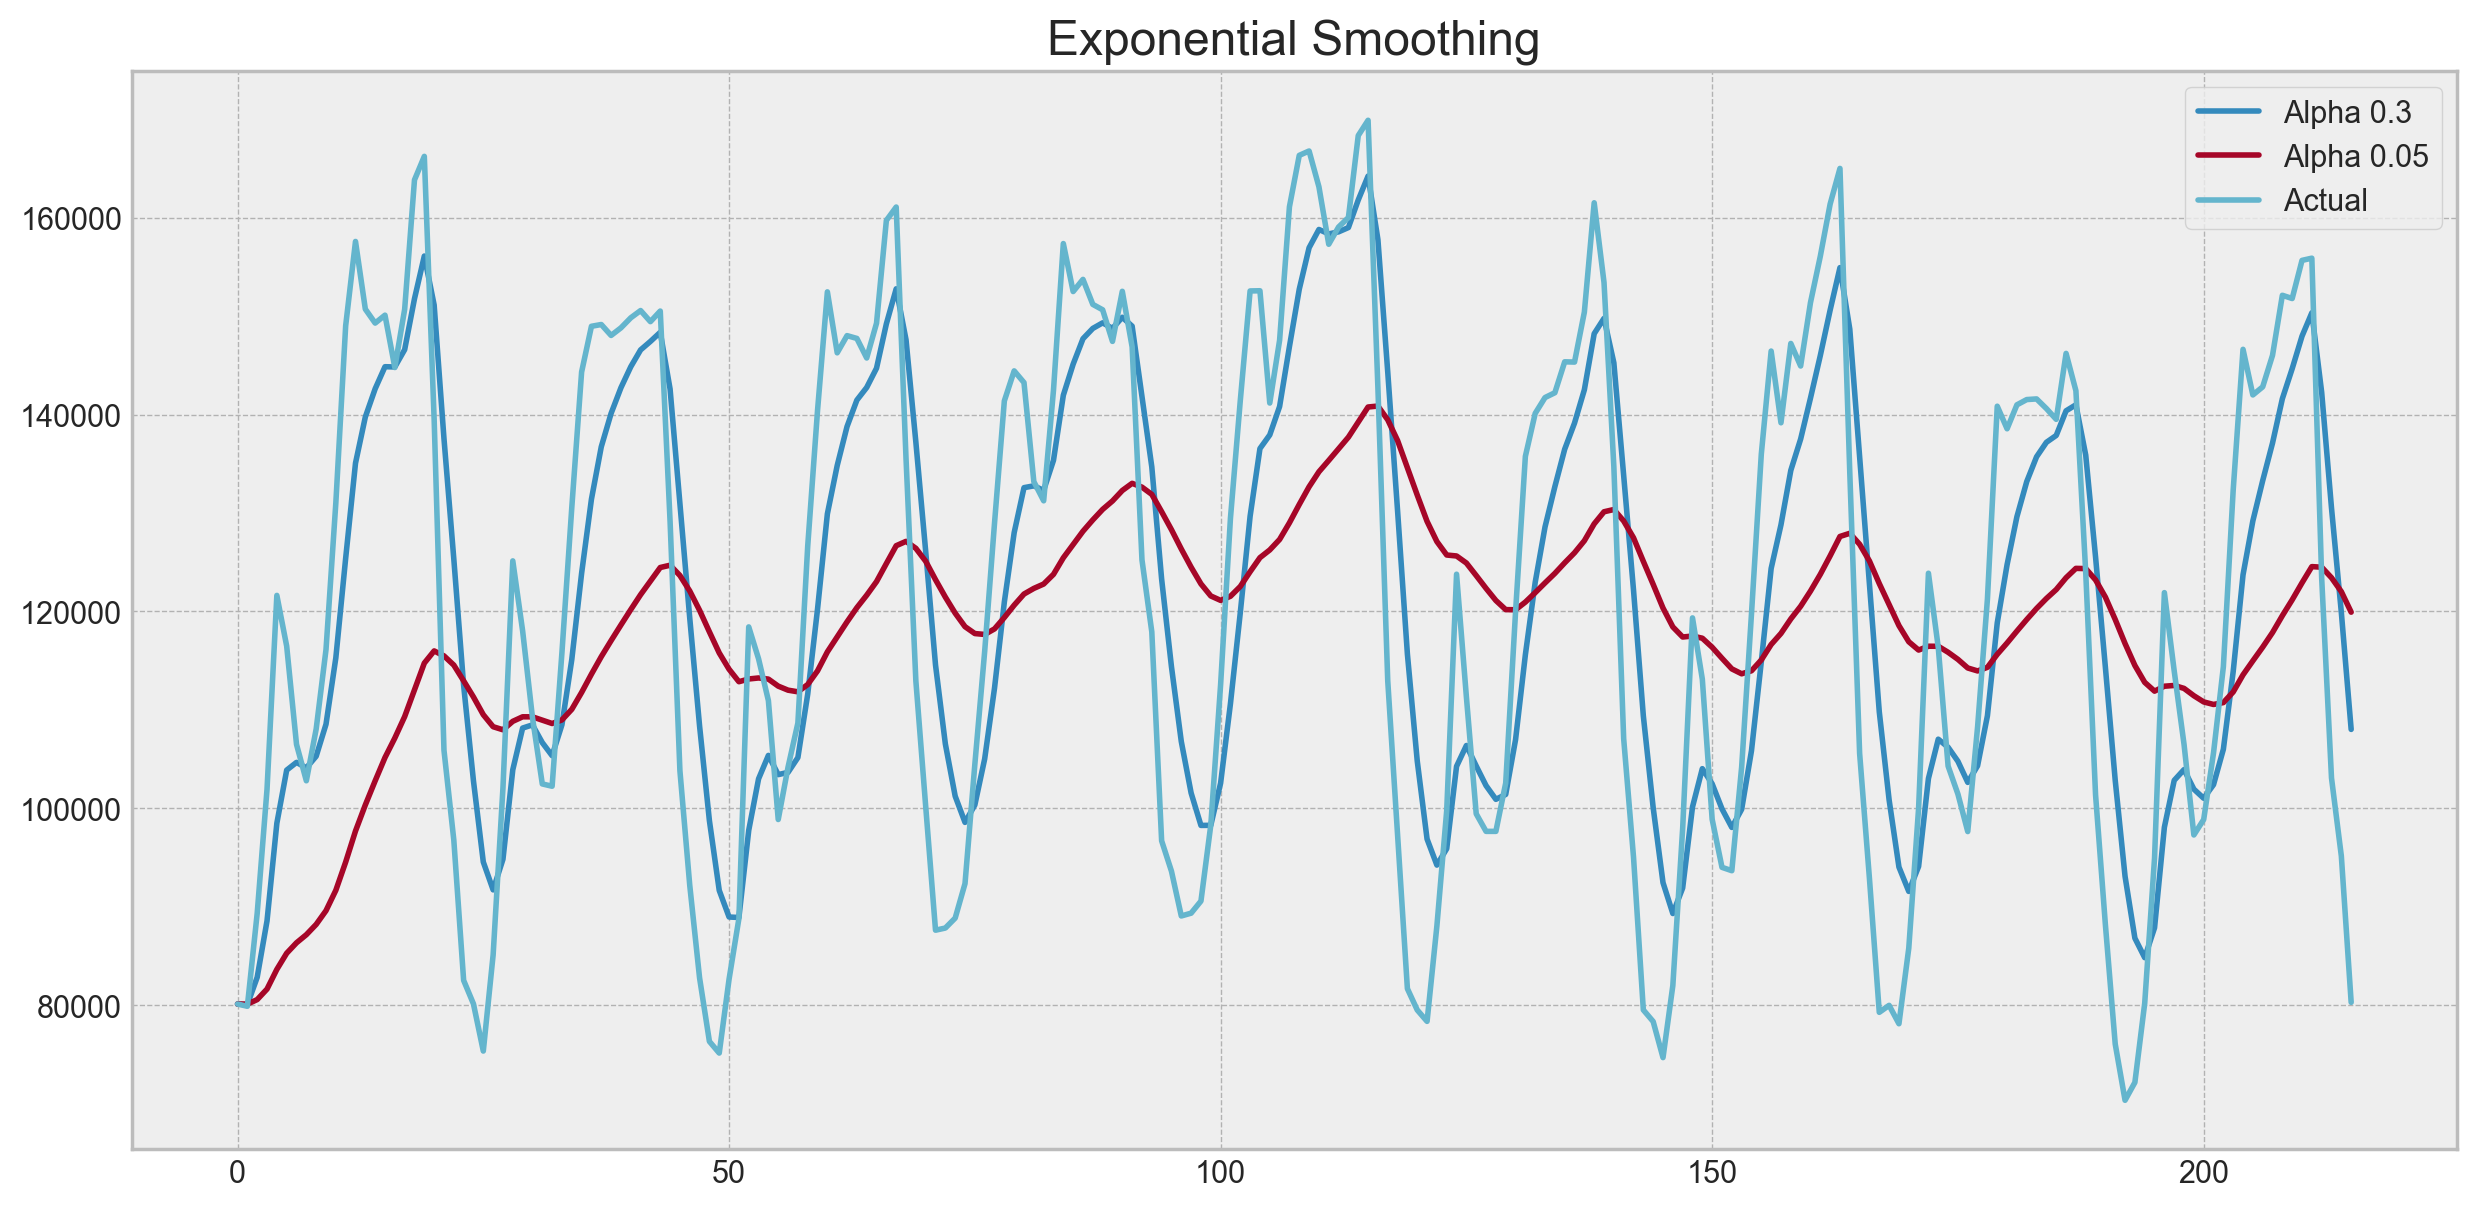

In [30]:
plotExponentialSmoothing(ads.Ads, [0.3, 0.05])

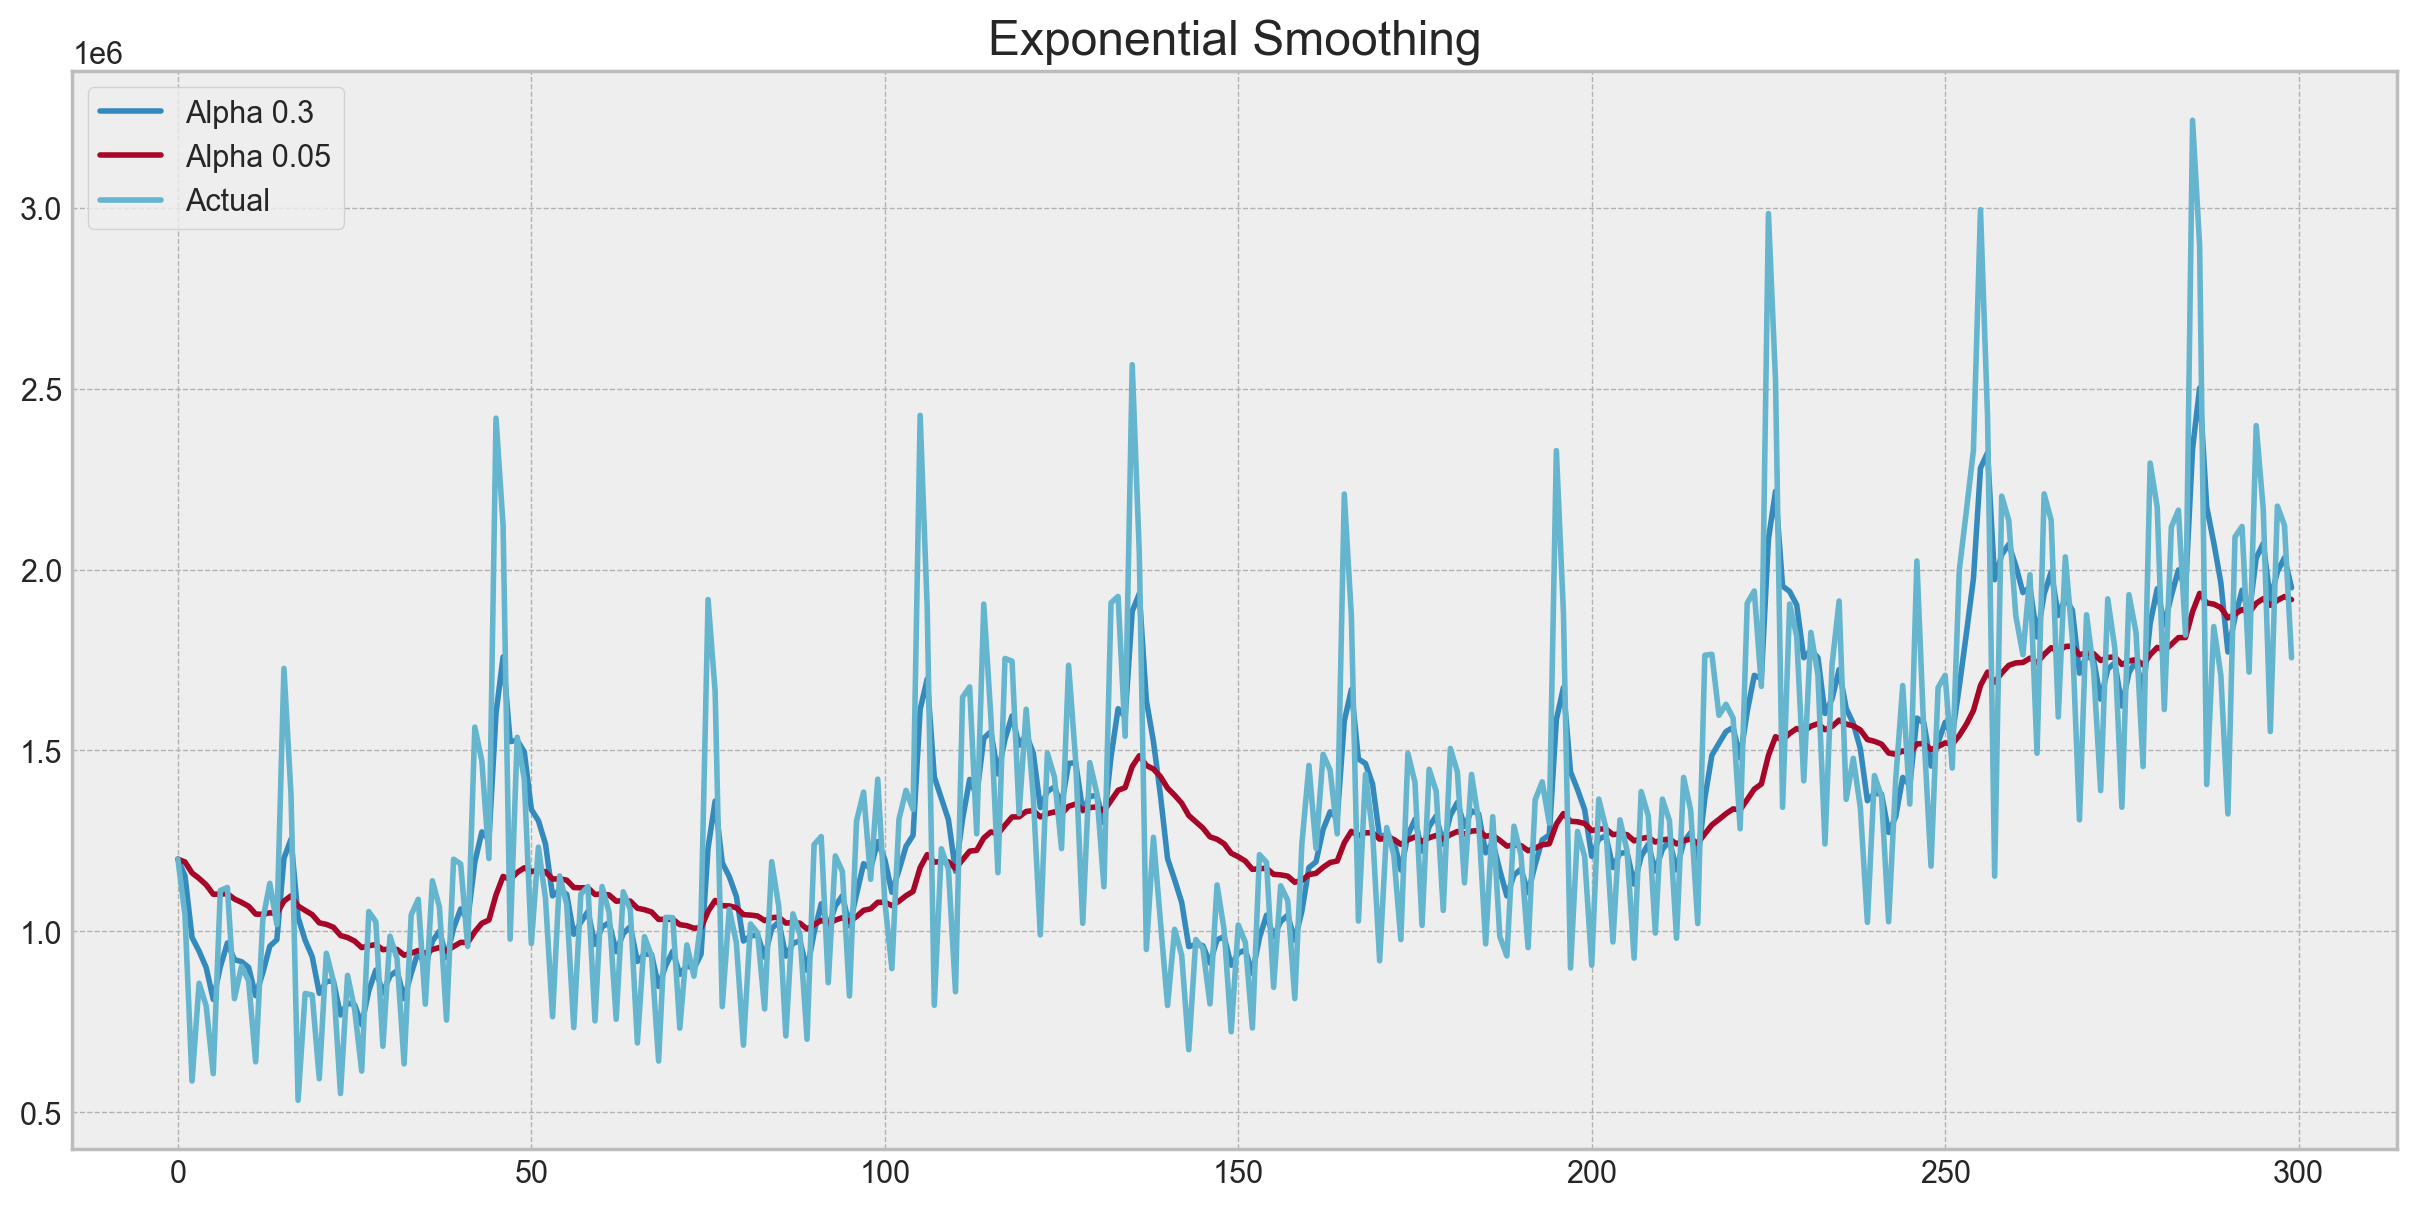

In [31]:
plotExponentialSmoothing(currency.GEMS_GEMS_SPENT, [0.3, 0.05])

## Double exponential smoothing

Up to now, the methods that we’ve discussed have been for a single future point prediction (with some nice smoothing). That is cool, but it is also not enough. Let’s extend exponential smoothing so that we can predict two future points 

In [32]:
def double_exponential_smoothing(series, alpha, beta):
    """
        series - dataset with timeseries
        alpha - float [0.0, 1.0], smoothing parameter for level
        beta - float [0.0, 1.0], smoothing parameter for trend
    """
    # first value is same as series
    result = [series[0]]
    for n in range(1, len(series) + 1):
        if n == 1:
            level, trend = series[0], series[1] - series[0]
        if n >= len(series):  # forecasting
            value = result[-1]
        else:
            value = series[n]
        last_level, level = level, alpha * value + (1 - alpha) * (level + trend)
        trend = beta * (level - last_level) + (1 - beta) * trend
        result.append(level + trend)
    return result


def plotDoubleExponentialSmoothing(series, alphas, betas):
    """
        Plots double exponential smoothing with different alphas and betas

        series - dataset with timestamps
        alphas - list of floats, smoothing parameters for level
        betas - list of floats, smoothing parameters for trend
    """

    with plt.style.context("bmh"):
        plt.figure(figsize=(20, 8))
        for alpha in alphas:
            for beta in betas:
                plt.plot(
                    double_exponential_smoothing(series, alpha, beta),
                    label="Alpha {}, beta {}".format(alpha, beta),
                )
        plt.plot(series.values, label="Actual")
        plt.legend(loc="best")
        plt.axis("tight")
        plt.title("Double Exponential Smoothing")
        plt.grid(True)

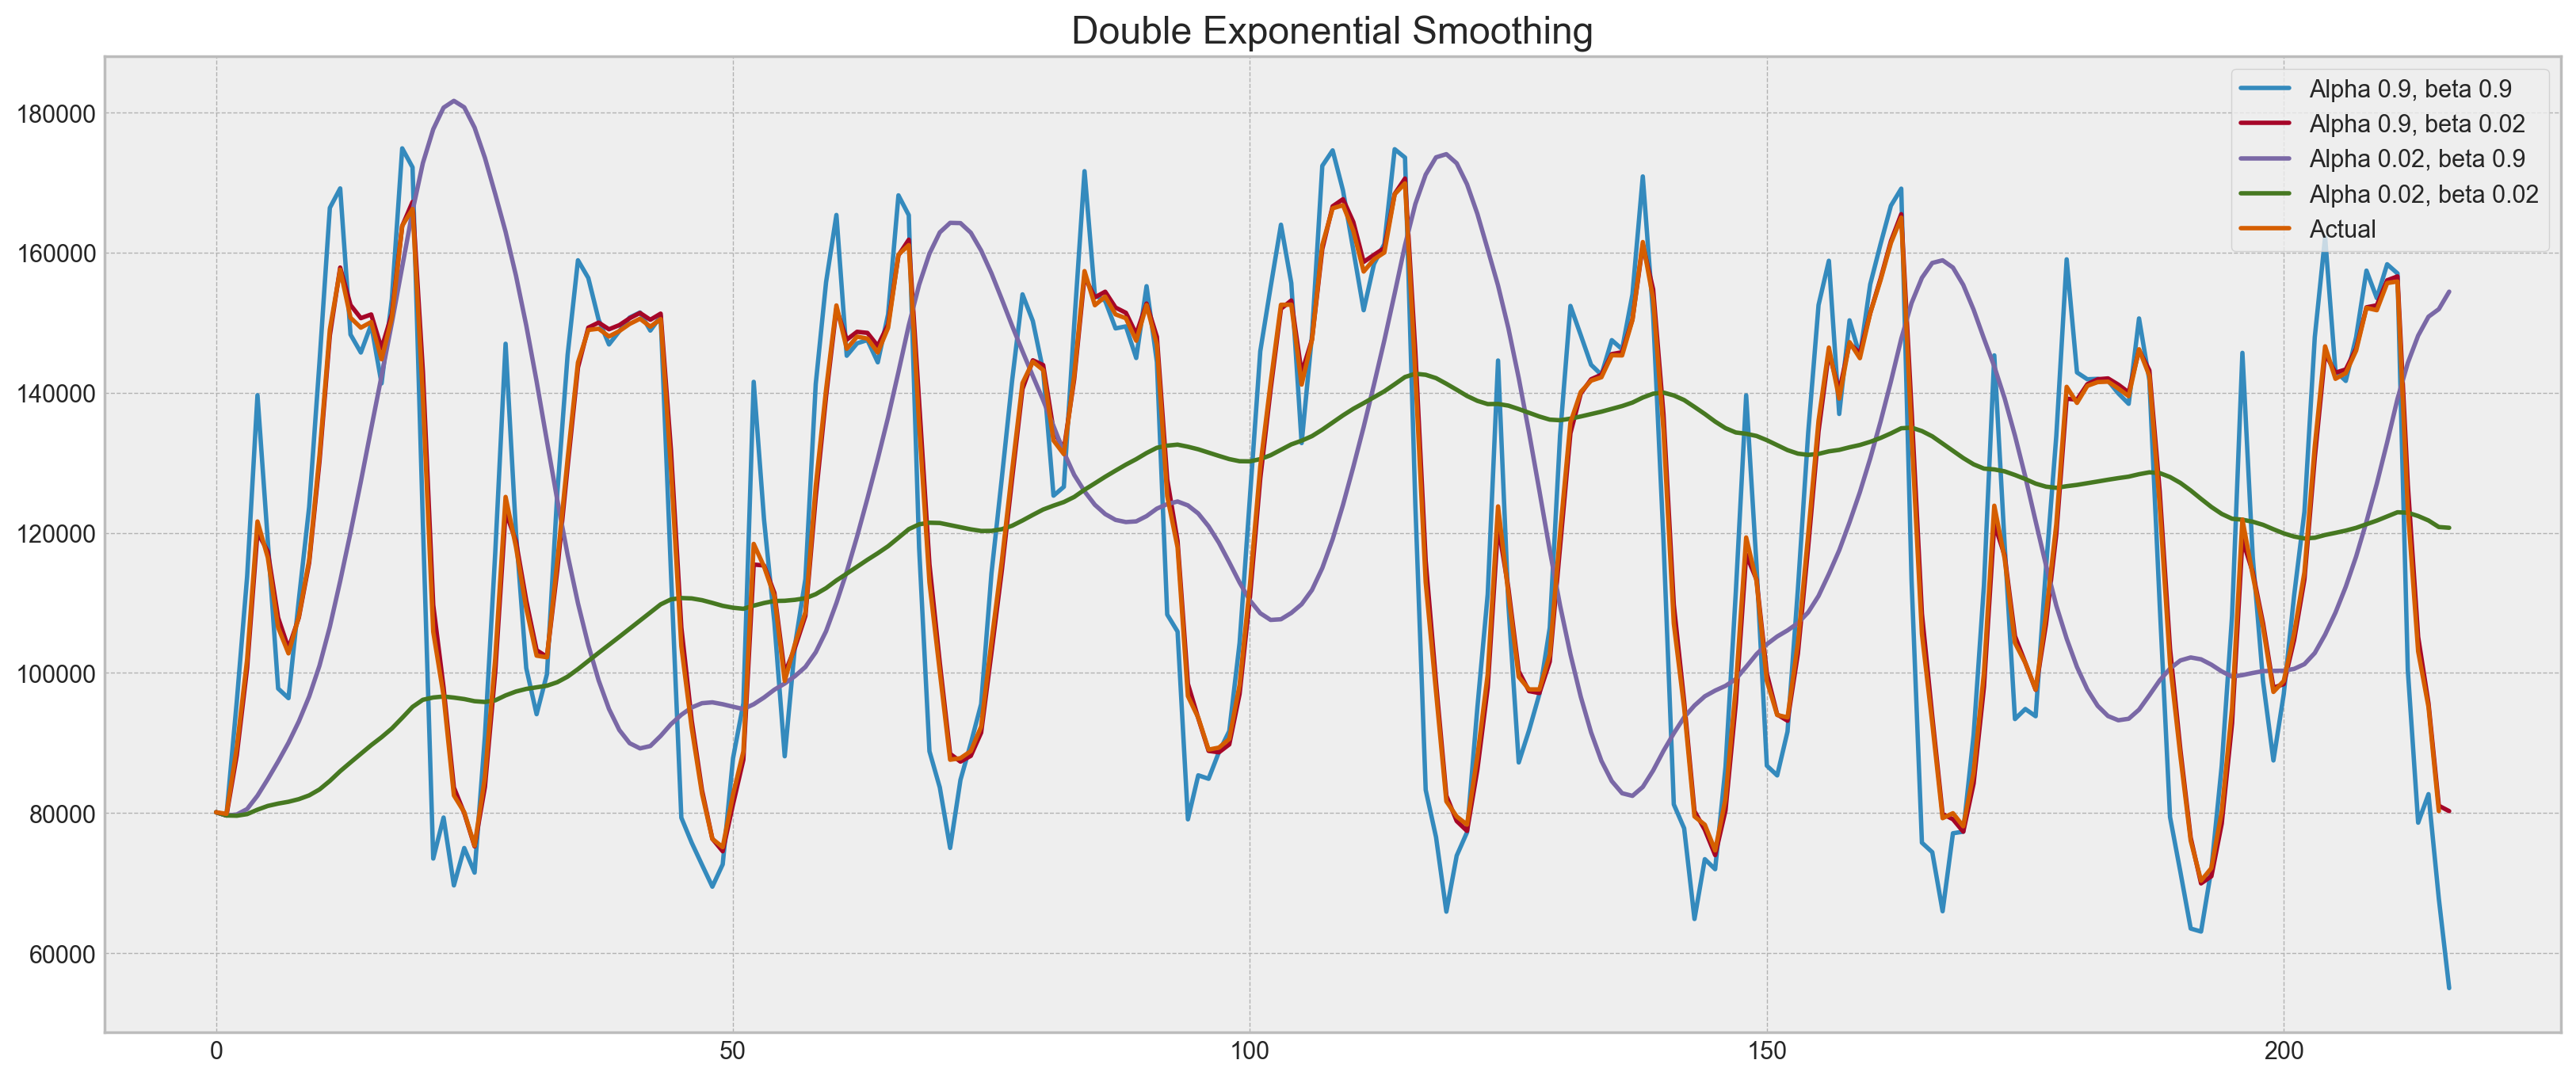

In [33]:
plotDoubleExponentialSmoothing(ads.Ads, alphas=[0.9, 0.02], betas=[0.9, 0.02])

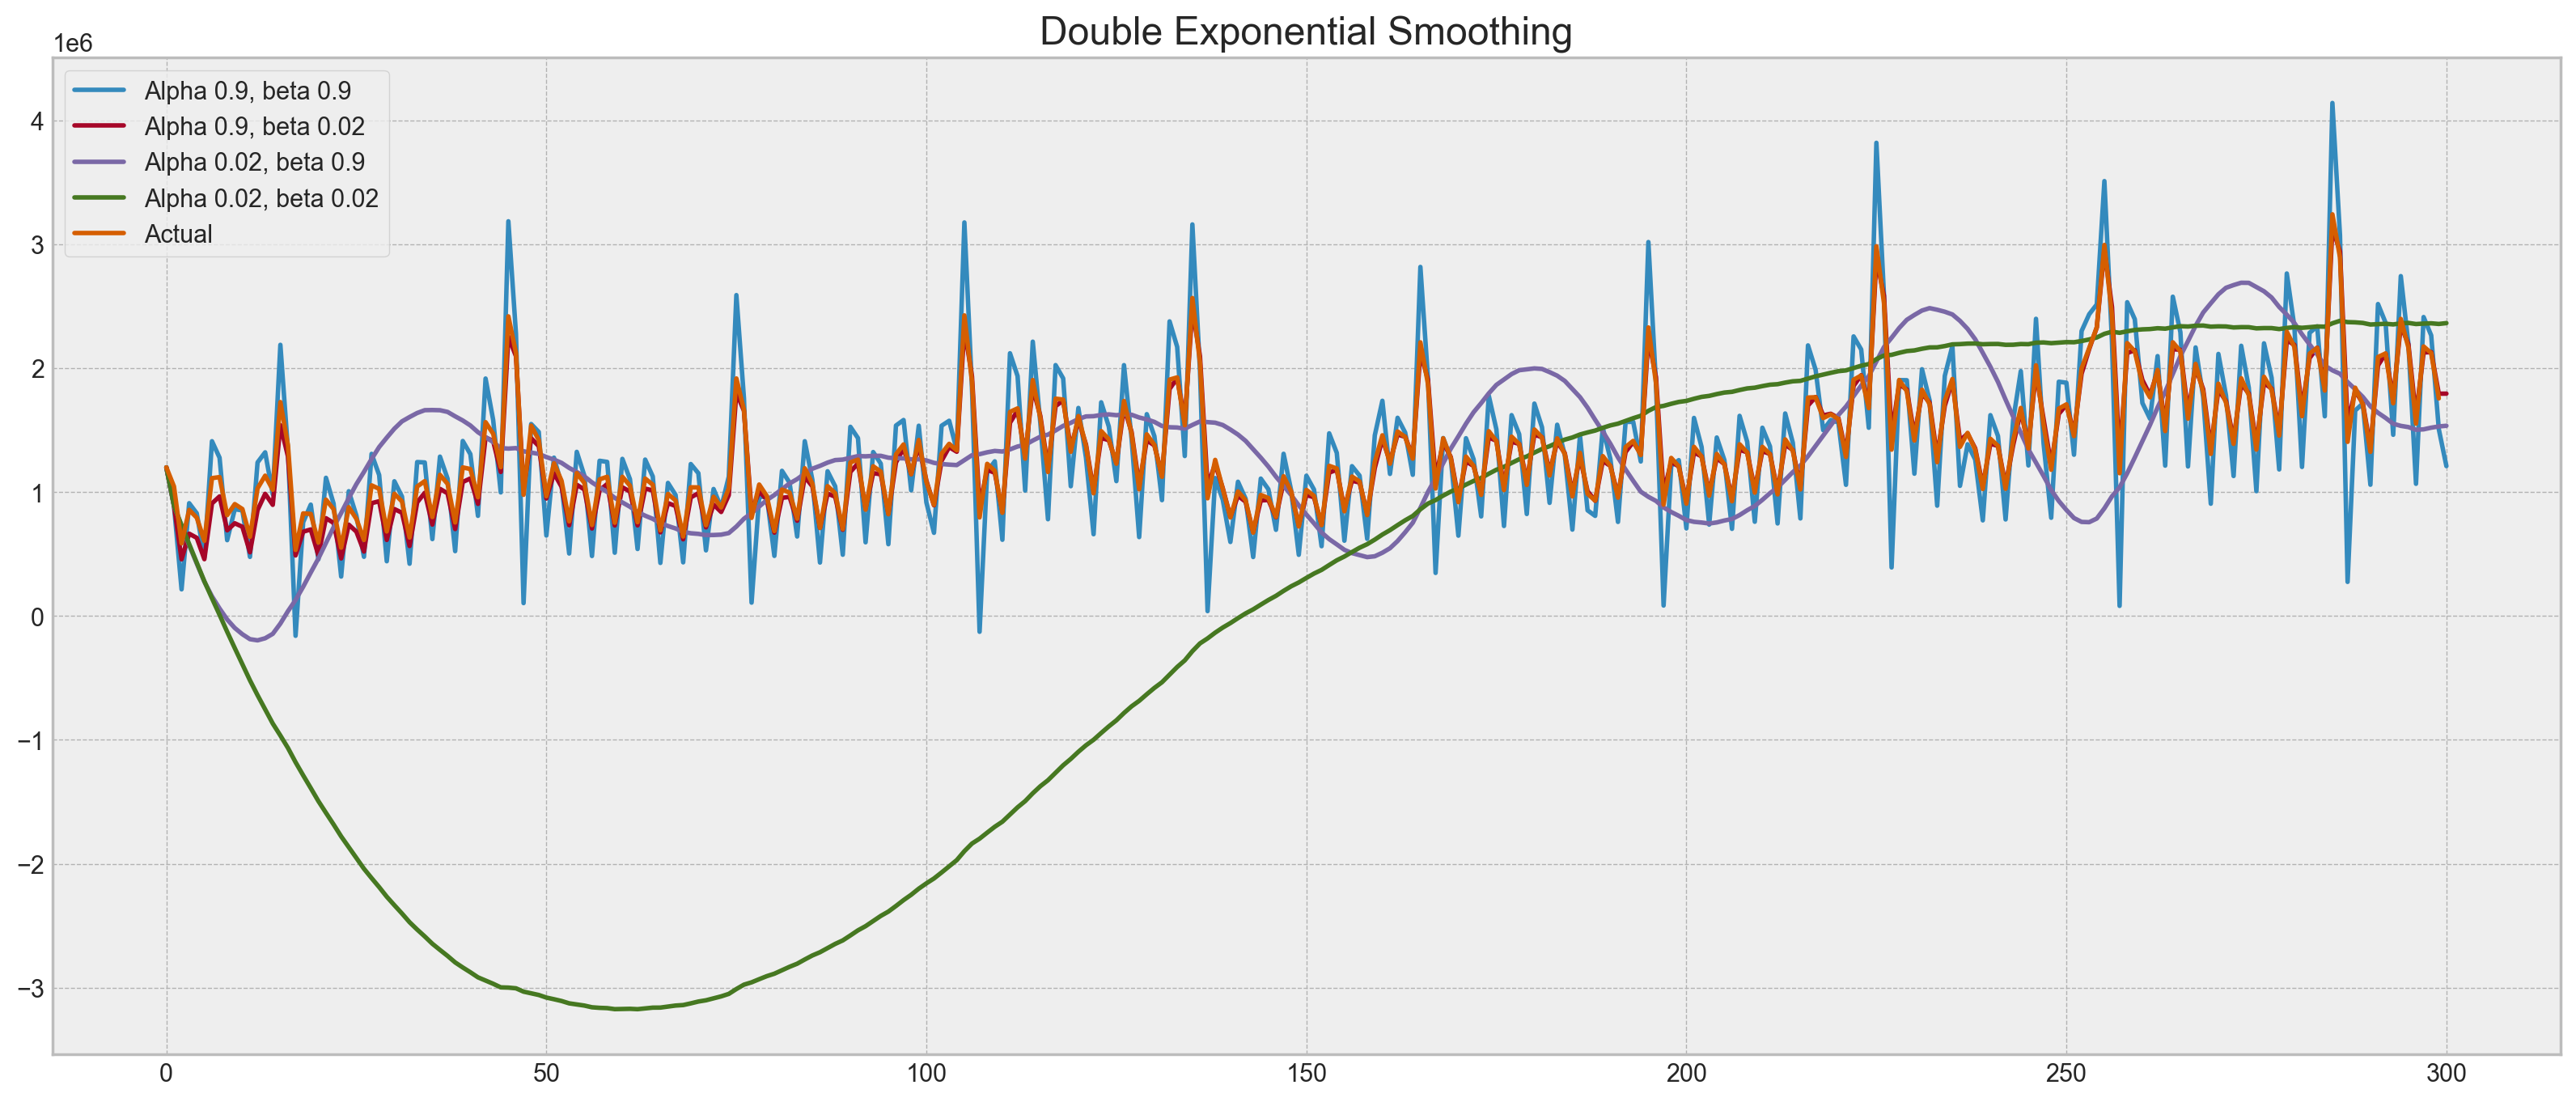

In [34]:
plotDoubleExponentialSmoothing(
    currency.GEMS_GEMS_SPENT, alphas=[0.9, 0.02], betas=[0.9, 0.02]
)

## Triple exponential smoothing a.k.a. Holt-Winters

Let's use your example:

```python
series = [10, 15, 20, 25, 14, 19, 24, 29]
slen = 4
```

The indices are:

| Index (`i`) | Value (`series[i]`) |
| ----------- | ------------------- |
| 0           | 10                  |
| 1           | 15                  |
| 2           | 20                  |
| 3           | 25                  |
| 4           | 14                  |
| 5           | 19                  |
| 6           | 24                  |
| 7           | 29                  |

Now the loop is:

```python
for i in range(slen):
```

Since `slen = 4`, `i` takes the values:

```python
i = 0, 1, 2, 3
```

For each `i`, here's what happens:

| `i` |      `series[i]` | `series[i + slen]` |    Difference |
| --: | ---------------: | -----------------: | ------------: |
|   0 | `series[0] = 10` |   `series[4] = 14` | `14 - 10 = 4` |
|   1 | `series[1] = 15` |   `series[5] = 19` | `19 - 15 = 4` |
|   2 | `series[2] = 20` |   `series[6] = 24` | `24 - 20 = 4` |
|   3 | `series[3] = 25` |   `series[7] = 29` | `29 - 25 = 4` |

So the line

```python
sum += float(series[i + slen] - series[i]) / slen
```

becomes:

```python
# i = 0
sum += (14 - 10) / 4   # = 1

# i = 1
sum += (19 - 15) / 4   # = 1

# i = 2
sum += (24 - 20) / 4   # = 1

# i = 3
sum += (29 - 25) / 4   # = 1
```

At the end:

```python
sum = 4
return sum / 4  # = 1
```

### Why compare `i` and `i + slen`?

Think of the series as two seasons:

```
Season 1         Season 2
Index 0  1  2  3 | 4  5  6  7
Value10 15 20 25 |14 19 24 29
      ↑           ↑
      same seasonal position

      ↑           ↑
      15          19

      ↑           ↑
      20          24

      ↑           ↑
      25          29
```

`series[i]` is a value in the **first season**, and `series[i + slen]` is the **corresponding value in the next season**. Comparing them estimates how much the series has grown (or shrunk) between two consecutive seasons, which is used to initialize the trend.


In [ ]:
series = [1,2,3,4,5,6,7,8,9,10,11,12,13,14]
slen = 7

a = []
b = []
for i in range(slen):
    a.append(series[i + slen])
    b.append(series[i])

a, b
print(len(series) / slen)

2.0


In [3]:
sum = 0.0
for i in range(slen):
    sum += float(series[i + slen] - series[i]) / slen
    print(sum / slen)

0.14285714285714285
0.2857142857142857
0.42857142857142855
0.5714285714285714
0.7142857142857143
0.8571428571428571
1.0


In [ ]:
class HoltWinters:
    def __init__(self, series, slen, alpha, beta, gamma, n_preds, scaling_factor=1.96):
        self.series = series
        self.slen = slen
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.n_preds = n_preds
        self.scaling_factor = scaling_factor

        def initial_trend(self):
            sum = 0.0
            for i in range(self.slen):
                sum += float(self.series[i + self.slen] - self.series[i]) / self.slen
            return sum / self.slen

        def initial_seasonal_components(self):
            seasonals = {}
            season_average = []
            n_seasons = int(len(self.series) / self.slen)

## Time series cross validation

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

def timeseriesCVscore(params, series, loss_function=mean_squared_error, slen=24):
    """
        Returns error on CV  

        params - vector of parameters for optimization
        series - dataset with timeseries
        slen - season length for Holt-Winters model
    """

    # errors array
    errors = []

    values = series.values
    alpha, beta, gamma = params

    # set the number of splits for cross validation

    tscv = TimeSeriesSplit(n_splits=3)

    # iterating over folds, train model on each, forecast and calculate error
    for train, test in tscv.split(values):
        model = holt
